# Multi-Product Supply Chain / Inventory Management System Optimisation
## Discrete-Event Simulation and (r, Q) Policy Optimisation — Python + SimPy

---

### Project Overview

This notebook implements a **multi-product supply chain inventory management system** that uses **SimPy discrete-event simulation (DES)** and **grid-search optimisation** to find the minimum-cost replenishment policy for each product.

#### Supply Chain Structure

| Component | Details |
|-----------|---------|
| **Products** | 3 SKUs (A, B, C) — distinct demand rates, lead times, and cost parameters |
| **Retailers** | 2 locations (North, South) — each holds independent inventory per product |
| **Warehouse** | 1 central hub — passive cost node (retailers order from external supplier); extendable to two-echelon model |
| **Policy** | Continuous-review **(r, Q)**: order Q units when inventory position ≤ r |

#### Inventory Position (IP)
> IP = on-hand + on-order − backorders
> When IP ≤ r → place one replenishment order for Q units

#### Cost Model
| Component | Formula | Trigger |
|-----------|---------|---------|
| Holding cost | h × max(0, on-hand) × Δt | Every event (time-weighted) |
| Shortage cost | p × backorders × Δt | Every event (time-weighted) |
| Ordering cost | K per order placed | Once per order |

> All costs are suppressed during a 30-day **warm-up period** to eliminate initialisation bias.

---

### Notebook Structure
1. Setup & Imports
2. Configuration Parameters
3. Core Data Models (Product, Inventory) — *inc. IP vs on-hand explanation, lost-sales mode, compound Poisson demand*
4. Supply Chain Locations (Retailer, Warehouse) — *inc. two-echelon extension notes*
5. SimPy Simulation Engine (Processes + Model)
6. Inventory Policy Optimiser (Grid Search + **Latin Hypercube Sampling**)
7. Helper & Visualisation Functions + **Export to Excel/JSON**
8. Demo: Single Simulation Run
9. Grid-Search Optimisation
10. Final Statistical Evaluation (15 replications, 95% CI)
11. Results Visualisation
12. Summary & Conclusions
13. **Sensitivity Analysis** (lead-time variability, shortage cost)
14. **Export Results** (Excel / JSON)

## 1. Setup & Imports

Install required packages (uncomment the `!pip install` line on first run), then import everything needed for simulation, optimisation, and visualisation.

In [ ]:
# Uncomment the line below on first run to install all dependencies
# !pip install simpy numpy scipy pandas matplotlib

import warnings
warnings.filterwarnings('ignore')

# Simulation engine
import simpy

# Numerical & statistical
import numpy as np
from scipy.stats import t as t_dist

# Data manipulation
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from IPython.display import display

# Python standard library
import copy, math, time
from dataclasses import dataclass, field
from abc import ABC, abstractmethod
from typing import Dict, List, Any, Optional, Tuple
from collections import defaultdict
from itertools import product as cartesian

%matplotlib inline
plt.rcParams.update({
    'figure.dpi':     110,
    'font.size':      10,
    'axes.grid':      True,
    'grid.alpha':     0.3,
    'figure.figsize': (12, 4),
})

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print('[OK] All packages loaded successfully.')
print(f'     simpy {simpy.__version__}  |  numpy {np.__version__}  |  pandas {pd.__version__}')

[OK] All packages loaded successfully.
     simpy 4.1.1  |  numpy 1.26.4  |  pandas 3.0.1


## 2. Configuration Parameters

All model parameters are stored in a single `CONFIG` dictionary — the **single source of truth** for the entire experiment. Changing values here propagates through optimisation, simulation, and reporting automatically.

Key tunable parameters:
- **`r_candidates`** — reorder-point values to evaluate during grid search
- **`Q_candidates`** — order-quantity values to evaluate during grid search
- **`service_level_target`** — minimum fill rate (95%) a policy must achieve to be considered feasible
- **`replications_per_eval`** — how many independent runs per (r, Q) cell during optimisation

In [ ]:
CONFIG = {
    # ------------------------------------------------------------------ #
    #  Products: 3 SKUs with different cost structures & demand profiles  #
    # ------------------------------------------------------------------ #
    'products': {
        'A': {
            'holding_cost':    2.00,   # $/unit/day on-hand
            'ordering_cost': 150.00,   # $/order placed
            'shortage_cost':  25.00,   # $/unit/day backordered
            'unit_cost':      10.00,   # $/unit purchased
            'demand_rate':     5.0,    # units/day (Poisson lambda)
            'lead_time_mean':  3.0,    # mean lead time (days)
            'lead_time_std':   0.5,    # std  lead time (days, log-normal)
            'initial_stock':  50,
        },
        'B': {
            'holding_cost':    3.50,
            'ordering_cost': 200.00,
            'shortage_cost':  40.00,
            'unit_cost':      25.00,
            'demand_rate':     3.0,
            'lead_time_mean':  5.0,
            'lead_time_std':   1.0,
            'initial_stock':  40,
        },
        'C': {
            'holding_cost':    1.00,
            'ordering_cost':  80.00,
            'shortage_cost':  15.00,
            'unit_cost':       5.00,
            'demand_rate':     8.0,
            'lead_time_mean':  2.0,
            'lead_time_std':   0.3,
            'initial_stock':  80,
        },
    },
    # ------------------------------------------------------------------ #
    #  Network: 2 retailers + 1 warehouse                                 #
    # ------------------------------------------------------------------ #
    'retailers': [
        {'id': 'R1', 'name': 'North Retailer'},
        {'id': 'R2', 'name': 'South Retailer'},
    ],
    'warehouse': {
        'id': 'W1', 'name': 'Central Warehouse',
        'holding_cost_multiplier':  0.5,
        'initial_stock_multiplier': 5,
    },
    # ------------------------------------------------------------------ #
    #  Simulation settings                                                 #
    # ------------------------------------------------------------------ #
    'simulation': {
        'horizon':         365.0,   # days per replication
        'warm_up_period':   30.0,   # days excluded from cost/service tracking
        'replications':     15,     # final-evaluation replications
        'random_seed_base': 42,
    },
    # ------------------------------------------------------------------ #
    #  Optimisation search space                                           #
    # ------------------------------------------------------------------ #
    'optimization': {
        'r_candidates':          [10, 15, 20, 25, 30],  # reorder-point candidates
        'Q_candidates':          [20, 40, 60, 80, 100], # order-quantity candidates
        'service_level_target':  0.95,                  # minimum fill rate
        'replications_per_eval': 8,                     # reps per (r,Q) cell
    },
}

# ---- Display product parameters as a formatted table -----------------
product_df = pd.DataFrame({
    pname: {
        'Demand Rate (units/day)':    params['demand_rate'],
        'Lead Time Mean (days)':      params['lead_time_mean'],
        'Lead Time Std (days)':       params['lead_time_std'],
        'Holding Cost ($/unit/day)':  params['holding_cost'],
        'Ordering Cost ($/order)':    params['ordering_cost'],
        'Shortage Cost ($/unit/day)': params['shortage_cost'],
        'Unit Cost ($/unit)':         params['unit_cost'],
        'Initial Stock (units)':      params['initial_stock'],
    }
    for pname, params in CONFIG['products'].items()
})
print('=== Product Parameters ===')
display(product_df)

# Theoretical EOQ and reorder-point reference values
print('\n=== Theoretical Reference Values (EOQ formula) ===')
ref_rows = []
for pname, p in CONFIG['products'].items():
    eoq   = int(np.sqrt(2 * p['ordering_cost'] * p['demand_rate'] / p['holding_cost']))
    e_dlt = p['demand_rate'] * p['lead_time_mean']
    ss    = int(1.65 * np.sqrt(p['demand_rate'] * p['lead_time_mean'] + p['demand_rate']**2 * p['lead_time_std']**2))
    ref_rows.append({'Product': pname, 'EOQ (Q*)': eoq,
                     'E[Demand in LT]': round(e_dlt,1),
                     'Safety Stock (z=1.65)': ss,
                     'Suggested r': int(e_dlt) + ss})
display(pd.DataFrame(ref_rows).set_index('Product'))

=== Product Parameters ===


,A,B,C
Demand Rate (units/day),5.0000,3.0000,8.0000
Lead Time Mean (days),3.0000,5.0000,2.0000
Lead Time Std (days),0.5000,1.0000,0.3000
Holding Cost ($/unit/day),2.0000,3.5000,1.0000
Ordering Cost ($/order),150.0000,200.0000,80.0000
Shortage Cost ($/unit/day),25.0000,40.0000,15.0000
Unit Cost ($/unit),10.0000,25.0000,5.0000
Initial Stock (units),50.0000,40.0000,80.0000



=== Theoretical Reference Values (EOQ formula) ===


,EOQ (Q*),E[Demand in LT],Safety Stock (z=1.65),Suggested r
Product,,,,
A,27,15.0000,7,22
B,18,15.0000,8,23
C,35,16.0000,7,23


## 3. Core Data Models

### 3a. `Product` — SKU Descriptor
A frozen-like dataclass that holds all static attributes of one SKU.  
The lead-time distribution is **log-normal** (always positive) — its parameters (`_lt_mu`, `_lt_sigma`) are derived in `__post_init__` from the user-supplied mean and standard deviation.

An optional `demand_distribution` field selects the demand model:
| Value | Behaviour |
|-------|-----------|
| `'poisson'` *(default)* | 1 unit per arrival; arrivals ~ Exp(1/λ) → Poisson(λ) process |
| `'compound_poisson'` | Arrivals at rate λ, each carrying a **geometric batch** with mean `compound_batch_mean` |

### 3b. `Inventory` — (r, Q) Tracker
The heart of the simulation. For each **(location, product)** pair it:
- Tracks `on_hand`, `on_order`, `backorders`, and `inventory_position`
- Accumulates **time-weighted** holding and shortage costs (excluding warm-up)
- Implements the **(r, Q) trigger**: `needs_replenishment()` + `trigger_order()`
- Records a **time-series history** for plotting
- Supports an optional **lost-sales mode** (`lost_sales=True`) where unmet demand disappears instead of being backordered

---

### Why inventory position (IP), not on-hand stock, drives the (r, Q) trigger

| Metric | Definition | What it captures |
|--------|------------|-----------------|
| **On-hand** | Physical units on the shelf right now | Current stock |
| **On-order** | Units ordered but not yet received | Pipeline stock |
| **Backorders** | Units promised but not yet fulfilled | Negative stock |
| **IP** = on-hand + on-order − backorders | Forward-looking net position | *Effective* stock once all in-flight orders arrive |

**Why use IP?** Under a continuous-review policy, a new order is placed the moment stock is needed — but there may already be one or more orders in transit. If we only looked at on-hand stock, we would over-order every time a demand event occurred while a replenishment was still in-flight, driving up holding costs unnecessarily. By using IP, the trigger fires only when the *expected* future stock (including orders already placed) drops below the safety margin `r`. This prevents duplicate orders during a single lead-time interval.

In [ ]:
# ==========================================================================
#  PRODUCT — immutable SKU descriptor
# ==========================================================================

@dataclass
class Product:
    '''Static attributes for one SKU (Stock-Keeping Unit).'''
    name:            str
    holding_cost:    float   # $/unit/day  on-hand
    ordering_cost:   float   # $/order placed
    shortage_cost:   float   # $/unit/day  backordered
    unit_cost:       float   # $/unit purchased
    demand_rate:     float   # units/day  (Poisson lambda)
    lead_time_mean:  float   # mean lead time (days)
    lead_time_std:   float   # std  lead time (days)
    initial_stock:   int     # starting on-hand units

    # Optional demand-distribution settings (default = standard Poisson)
    demand_distribution: str   = 'poisson'   # 'poisson' or 'compound_poisson'
    compound_batch_mean: float = 1.0          # mean batch size (compound_poisson only)

    # Log-normal parameters derived in __post_init__ (not constructor args)
    _lt_mu:    float = field(init=False, default=0.0, repr=False)
    _lt_sigma: float = field(init=False, default=0.0, repr=False)

    def __post_init__(self):
        '''Fit log-normal(mu, sigma) from (mean, std) so lead times stay > 0.'''
        mu = self.lead_time_mean
        s  = self.lead_time_std
        self._lt_sigma = float(np.sqrt(np.log(1.0 + (s / mu) ** 2)))
        self._lt_mu    = float(np.log(mu) - 0.5 * self._lt_sigma ** 2)

    def sample_lead_time(self, rng):
        '''Draw one log-normal lead-time sample (days).'''
        return float(rng.lognormal(mean=self._lt_mu, sigma=self._lt_sigma))

    def sample_inter_arrival(self, rng):
        '''Exponential inter-arrival time for a Poisson demand stream.'''
        return float(rng.exponential(scale=1.0 / self.demand_rate))

    def sample_demand_batch(self, rng):
        '''Units demanded per arrival event.

        - ``poisson``          : always 1 unit (standard Poisson process)
        - ``compound_poisson`` : geometric batch with mean = compound_batch_mean
          (variance > mean → overdispersed demand; approaches Poisson as mean → 1)
        '''
        if self.demand_distribution == 'compound_poisson':
            p = 1.0 / max(self.compound_batch_mean, 1.0)
            return int(rng.geometric(p))
        return 1

    @classmethod
    def from_config(cls, name, params):
        return cls(name=name, **params)


# ==========================================================================
#  INVENTORY — continuous-review (r, Q) tracker
# ==========================================================================

@dataclass
class InventorySnapshot:
    '''One row in the time-series history used for plotting.'''
    time: float; on_hand: int; backorders: int
    on_order: int; inventory_position: int


class Inventory:
    '''
    Tracks stock levels and cumulative costs for one (location, product) pair.

    (r, Q) Policy
    -------------
    inventory_position = on_hand + on_order - backorders
    When IP <= r  ->  place one order for Q units.
    '''

    def __init__(self, product, initial_stock, reorder_point,
                 order_quantity, location_id, warm_up_period=30.0,
                 lost_sales=False):
        self.product        = product
        self.location_id    = location_id
        self.warm_up_period = warm_up_period
        self.reorder_point  = reorder_point    # r
        self.order_quantity = order_quantity   # Q
        self.lost_sales     = lost_sales       # True → unmet demand is lost, not backordered

        # Stock state
        self.on_hand    = initial_stock
        self.on_order   = 0
        self.backorders = 0

        # Cost accumulators (post warm-up only)
        self._last_time          = 0.0
        self.total_holding_cost  = 0.0
        self.total_shortage_cost = 0.0
        self.total_ordering_cost = 0.0
        self.num_orders          = 0

        # Demand counters
        self.total_demand              = 0
        self.units_filled_immediately  = 0
        self.units_backordered         = 0
        self.units_lost                = 0   # only incremented when lost_sales=True

        # Time-series for visualisation
        self.history = []

    @property
    def inventory_position(self):
        return self.on_hand + self.on_order - self.backorders

    @property
    def fill_rate(self):
        '''Fraction of demand satisfied immediately (no waiting).'''
        return self.units_filled_immediately / self.total_demand if self.total_demand else 1.0

    @property
    def total_cost(self):
        return self.total_holding_cost + self.total_shortage_cost + self.total_ordering_cost

    def _accrue_costs(self, t_now):
        '''Time-weighted cost accrual between events (warm-up excluded).'''
        t_start = max(self._last_time, self.warm_up_period)
        t_end   = max(t_now,           self.warm_up_period)
        dt = t_end - t_start
        if dt > 0.0:
            self.total_holding_cost  += self.product.holding_cost  * max(0, self.on_hand)    * dt
            self.total_shortage_cost += self.product.shortage_cost * max(0, self.backorders) * dt
        self._last_time = t_now

    def _snapshot(self, t):
        self.history.append(InventorySnapshot(
            time=t, on_hand=self.on_hand, backorders=self.backorders,
            on_order=self.on_order, inventory_position=self.inventory_position))

    # ------------------------------------------------------------------
    #  Public API called by SimPy processes
    # ------------------------------------------------------------------

    def satisfy_demand(self, qty, t):
        '''Process demand of qty units at time t. Returns units unfulfilled.

        Backorder mode (default, lost_sales=False):
            Unmet demand accumulates as backorders; filled when next order arrives.
        Lost-sales mode (lost_sales=True):
            Unmet demand is recorded in units_lost and discarded permanently.
            Note: shortage cost is still applied per unit-day of lost demand
            (i.e. the cost rate reflects lost-sale penalty, not backorder holding).
        '''
        self._accrue_costs(t)
        self.total_demand += qty
        filled = min(qty, self.on_hand)
        short  = qty - filled
        self.on_hand                  -= filled
        self.units_filled_immediately += filled
        if short > 0:
            if self.lost_sales:
                self.units_lost += short
                # Accrue one-period penalty equivalent (instantaneous, not time-weighted)
                if t > self.warm_up_period:
                    self.total_shortage_cost += self.product.shortage_cost * short
            else:
                self.backorders        += short
                self.units_backordered += short
        self._snapshot(t)
        return short

    def needs_replenishment(self):
        return self.inventory_position <= self.reorder_point

    def trigger_order(self, t):
        '''Place order for Q units if IP <= r. Returns Q or 0.'''
        if not self.needs_replenishment():
            return 0
        Q = self.order_quantity
        self.on_order += Q
        if t > self.warm_up_period:
            self.total_ordering_cost += self.product.ordering_cost
            self.num_orders          += 1
        return Q

    def receive_delivery(self, qty, t):
        '''Accept delivery; fill backorders first, shelve remainder.'''
        self._accrue_costs(t)
        self.on_order = max(0, self.on_order - qty)
        fill    = min(qty, self.backorders)
        surplus = qty - fill
        self.backorders -= fill
        self.on_hand    += surplus
        self._snapshot(t)

    def get_metrics(self):
        return {
            'location_id':              self.location_id,
            'product':                  self.product.name,
            'reorder_point':            self.reorder_point,
            'order_quantity':           self.order_quantity,
            'lost_sales_mode':          self.lost_sales,
            'demand_distribution':      self.product.demand_distribution,
            'total_cost':               round(self.total_cost,              2),
            'holding_cost':             round(self.total_holding_cost,       2),
            'shortage_cost':            round(self.total_shortage_cost,      2),
            'ordering_cost':            round(self.total_ordering_cost,      2),
            'fill_rate':                round(self.fill_rate,                4),
            'total_demand':             self.total_demand,
            'units_filled_immediately': self.units_filled_immediately,
            'units_backordered':        self.units_backordered,
            'units_lost':               self.units_lost,
            'num_orders':               self.num_orders,
        }

print('[OK] Product and Inventory classes defined.')

[OK] Product and Inventory classes defined.


## 4. Supply Chain Locations

### `Location` (Abstract Base)
Provides a common interface — `get_all_metrics()`, `total_cost()`, `overall_fill_rate()` — for any stock-holding node.

### `Retailer`
Faces end-customer Poisson demand. Holds one `Inventory` object per product. Each retailer orders replenishment stock **directly from an infinite-capacity external supplier** — there is no physical link to the warehouse in this model. The replenishment lead time is sampled from a log-normal distribution per product.

### `Warehouse`
Central distribution hub. Tracks its own inventory at a **reduced holding cost** (50% of retail).

> **Current model scope (single-echelon):** The warehouse is a **passive cost node** — it holds stock and accrues holding costs, but retailer orders bypass it entirely (they go straight to the external supplier). The warehouse does *not* fulfil retailer orders. This simplification allows independent per-retailer (r, Q) optimisation.
>
> **Two-echelon extension:** To model a true two-echelon system where retailers replenish from the warehouse (and the warehouse in turn orders from the external supplier), register warehouse demand processes in `SupplyChainModel._register_processes()` and replace the retailer's supplier with a warehouse `simpy.Container`.

> **Warehouse (r, Q) heuristic:** `Warehouse._build_inventories` sets the warehouse reorder point and order quantity to 3× the retailer values. This is a simple scaling heuristic — in a true two-echelon model the warehouse policy should be optimised separately (e.g., using Clark–Scarf or a joint simulation-optimisation approach).

In [ ]:
# ==========================================================================
#  LOCATION — abstract base class for any stock-holding node
# ==========================================================================

class Location(ABC):
    '''Abstract base for a supply-chain node that holds physical stock.'''

    def __init__(self, id, name):
        self.id          = id
        self.name        = name
        self.inventories = {}   # product_name -> Inventory

    @abstractmethod
    def _build_inventories(self, products, policy, warm_up_period):
        ...

    def get_all_metrics(self):
        return [inv.get_metrics() for inv in self.inventories.values()]

    def total_cost(self):
        return sum(inv.total_cost for inv in self.inventories.values())

    def overall_fill_rate(self):
        demand = sum(inv.total_demand            for inv in self.inventories.values())
        filled = sum(inv.units_filled_immediately for inv in self.inventories.values())
        return filled / demand if demand > 0 else 1.0

    def __repr__(self):
        return f'{self.__class__.__name__}(id={self.id!r})'


# ==========================================================================
#  RETAILER — faces end-customer demand
# ==========================================================================

class Retailer(Location):
    '''Retail outlet with independent (r, Q) inventory per product.'''

    def __init__(self, id, name, products, policy, warm_up_period=30.0):
        super().__init__(id=id, name=name)
        self._build_inventories(products, policy, warm_up_period)

    def _build_inventories(self, products, policy, warm_up_period):
        for pname, product in products.items():
            p = policy.get(pname, {})
            self.inventories[pname] = Inventory(
                product        = product,
                initial_stock  = product.initial_stock,
                reorder_point  = p.get('r', 10),
                order_quantity = p.get('Q', 50),
                location_id    = self.id,
                warm_up_period = warm_up_period,
            )


# ==========================================================================
#  WAREHOUSE — central hub (passive cost node)
# ==========================================================================

class Warehouse(Location):
    '''
    Central distribution warehouse.
    Holding cost = product.holding_cost * holding_cost_multiplier.
    Extend to two-echelon by activating warehouse demand processes.
    '''

    def __init__(self, id, name, products, policy,
                 holding_cost_multiplier=0.5,
                 initial_stock_multiplier=5,
                 warm_up_period=30.0):
        super().__init__(id=id, name=name)
        self.hc_mult    = holding_cost_multiplier
        self.stock_mult = initial_stock_multiplier
        self._build_inventories(products, policy, warm_up_period)

    def _build_inventories(self, products, policy, warm_up_period):
        for pname, product in products.items():
            wh_product              = copy.copy(product)
            wh_product.holding_cost = product.holding_cost * self.hc_mult
            p = policy.get(pname, {})
            self.inventories[pname] = Inventory(
                product        = wh_product,
                initial_stock  = product.initial_stock * self.stock_mult,
                reorder_point  = p.get('r', 10) * 3,   # heuristic: 3× retail r; optimise separately for a true two-echelon model
                order_quantity = p.get('Q', 50) * 3,   # heuristic: 3× retail Q; replace with Clark-Scarf or joint optimisation
                location_id    = self.id,
                warm_up_period = warm_up_period,
            )

print('[OK] Location, Retailer, and Warehouse classes defined.')

[OK] Location, Retailer, and Warehouse classes defined.


## 5. SimPy Simulation Engine

### `demand_generator` (SimPy process)
A **forever-running generator** for one (retailer, product) pair.  
- Demand arrives at rate λ units/day — inter-arrival times ~ **Exp(1/λ)** (Poisson process)
- Each arrival = 1 unit; calls `inventory.satisfy_demand()`
- After each demand event, checks the **(r, Q) trigger** and spawns `delivery_process` if needed

### `delivery_process` (SimPy process)
Models the **transit delay** between order placement and receipt.  
- Lead time ~ **LogNormal(μ, σ)** calibrated from product mean & std
- Multiple orders can be in-flight simultaneously (one process per order)

### `SupplyChainModel`
Orchestrates **one complete replication**:  
- Creates all `Product`, `Retailer`, `Warehouse` objects  
- Registers a `demand_generator` for every (retailer × product) pair  
- Calls `env.run(until=horizon)` to advance the clock  
- `get_performance_metrics()` aggregates KPIs across all inventories

In [ ]:
# ==========================================================================
#  SimPy PROCESSES
# ==========================================================================

def demand_generator(env, inventory, product, rng):
    '''
    Continuous Poisson demand process for one (location, product) pair.

    Each demand event consumes 1 unit. After every event the (r,Q)
    trigger is checked; if IP <= r a new delivery_process is spawned.
    '''
    # Initial order check (handles cases where initial stock < r)
    if inventory.needs_replenishment():
        qty = inventory.trigger_order(env.now)
        if qty > 0:
            env.process(delivery_process(env, inventory, product, qty, rng))

    while True:
        inter_arrival = product.sample_inter_arrival(rng)
        yield env.timeout(inter_arrival)

        # Batch size = 1 for standard Poisson; geometric sample for compound Poisson
        inventory.satisfy_demand(product.sample_demand_batch(rng), env.now)

        if inventory.needs_replenishment():
            qty = inventory.trigger_order(env.now)
            if qty > 0:
                env.process(delivery_process(env, inventory, product, qty, rng))


def delivery_process(env, inventory, product, quantity, rng):
    '''
    Models the stochastic transit delay from order placement to receipt.
    Lead time ~ LogNormal.  Multiple orders can be in-flight simultaneously.
    '''
    lead_time = product.sample_lead_time(rng)
    yield env.timeout(lead_time)
    inventory.receive_delivery(quantity, env.now)


# ==========================================================================
#  SUPPLY CHAIN MODEL — one complete replication
# ==========================================================================

class SupplyChainModel:
    '''
    Ties together all products, retailers, and SimPy processes for one run.

    Parameters
    ----------
    env    : simpy.Environment    (fresh per replication)
    policy : dict                 {product_name: {'r': int, 'Q': int}, ...}
    config : dict                 CONFIG dictionary (or single-product slice)
    rng    : np.random.Generator  seeded generator unique to this replication
    '''

    def __init__(self, env, policy, config, rng):
        self.env    = env
        self.policy = policy
        self.config = config
        self.rng    = rng
        warm_up     = config['simulation']['warm_up_period']

        # Build product catalog
        self.products = {
            name: Product.from_config(name, params)
            for name, params in config['products'].items()
        }

        # Build warehouse (passive cost node)
        wh = config['warehouse']
        self.warehouse = Warehouse(
            id=wh['id'], name=wh['name'],
            products=self.products, policy=policy,
            holding_cost_multiplier =wh['holding_cost_multiplier'],
            initial_stock_multiplier=wh['initial_stock_multiplier'],
            warm_up_period=warm_up,
        )

        # Build retailers
        self.retailers = {}
        for r_cfg in config['retailers']:
            retailer = Retailer(
                id=r_cfg['id'], name=r_cfg['name'],
                products=self.products, policy=policy,
                warm_up_period=warm_up,
            )
            self.retailers[r_cfg['id']] = retailer

    def _register_processes(self):
        '''Start demand_generator for every (retailer, product) pair.'''
        for retailer in self.retailers.values():
            for pname, product in self.products.items():
                self.env.process(
                    demand_generator(self.env, retailer.inventories[pname],
                                     product, self.rng)
                )

    def run(self, until):
        self._register_processes()
        self.env.run(until=until)

    def get_performance_metrics(self):
        '''Aggregate cost and fill-rate across all retailers and products.'''
        detail       = []
        total_cost   = 0.0
        total_demand = 0
        total_filled = 0

        for retailer in self.retailers.values():
            for inv in retailer.inventories.values():
                m = inv.get_metrics()
                detail.append(m)
                total_cost   += m['total_cost']
                total_demand += m['total_demand']
                total_filled += m['units_filled_immediately']

        service_level = total_filled / total_demand if total_demand > 0 else 1.0
        return {
            'total_cost':    round(total_cost, 2),
            'service_level': round(service_level, 4),
            'detail':        detail,
        }

print('[OK] SimPy processes and SupplyChainModel defined.')

[OK] SimPy processes and SupplyChainModel defined.


## 6. Inventory Policy Optimiser

### Strategy: Decoupled Per-Product Grid Search

Products are optimised **independently** because they share no resource (no warehouse capacity constraint in this model). For each product:

1. A **single-product config slice** is created (only one product active)
2. All `(r, Q)` combinations from the search grid are evaluated
3. Each combination runs `replications_per_eval` independent SimPy replications
4. The cheapest combination satisfying the **95% fill-rate constraint** is selected
5. Optimal per-product policies are combined into a **joint policy**

**Computational complexity (full grid search):**  
`|r_candidates| × |Q_candidates| × n_products × reps_per_eval`  
= 5 × 5 × 3 × 8 = **600 simulation runs** (typically < 2 minutes)

**Latin Hypercube Sampling (LHS) alternative:**  
Call `optimizer.optimize(use_lhs=True)` to replace the full factorial sweep with a space-filling LHS design. Set `config['optimization']['lhs_samples']` to control the number of sample points (default 15). LHS evaluates fewer combinations while maintaining coverage of the (r, Q) space — useful when the candidate grid is large or when products/replications increase run time significantly.

### Fallback
If no `(r, Q)` combination achieves the target service level, the combination with the **highest fill rate** is used and a warning is printed.

In [ ]:
# ==========================================================================
#  INVENTORY OPTIMIZER — decoupled per-product grid search
# ==========================================================================

class InventoryOptimizer:
    '''
    Grid-search optimiser for (r, Q) inventory policies.

    Each product is optimised independently using single-product simulation
    runs.  Products are then combined into a joint policy for final reporting.
    '''

    def __init__(self, config):
        self.config  = config
        self.opt_cfg = config['optimization']
        self.sim_cfg = config['simulation']
        self.best_policy        = None
        self.best_cost          = float('inf')
        self.best_service_level = 0.0
        self.results            = []   # full search table for analysis

    # ------------------------------------------------------------------
    def optimize(self, use_lhs=False):
        '''Run per-product optimisation. Returns the best joint policy.

        Parameters
        ----------
        use_lhs : bool
            If True, use Latin Hypercube Sampling (LHS) instead of full grid
            search.  LHS draws a space-filling design of ``lhs_samples`` points
            over the (r, Q) candidate space.  Useful when the search grid is
            large — it evaluates fewer combinations while maintaining coverage.
            Set ``config['optimization']['lhs_samples']`` to control sample
            count (default 15).
        '''
        product_names = list(self.config['products'].keys())
        joint_policy  = {}
        t0 = time.time()
        search_label = 'LHS' if use_lhs else 'Grid Search'

        for pname in product_names:
            print(f'\n  --- Optimising Product {pname} ({search_label}) ---')
            if use_lhs:
                n_lhs = self.opt_cfg.get('lhs_samples', 15)
                best_r, best_Q, best_cost = self._lhs_search_product(pname, n_samples=n_lhs)
            else:
                best_r, best_Q, best_cost = self._grid_search_product(pname)
            joint_policy[pname] = {'r': best_r, 'Q': best_Q}
            print(f'      Best: r={best_r}, Q={best_Q}, cost=${best_cost:,.2f}')

        elapsed = time.time() - t0
        print(f'\n  [Done] Total optimisation time: {elapsed:.1f}s')

        # Final joint evaluation over full config
        cost, service = self._evaluate_policy(joint_policy, self.config,
                                              self.opt_cfg['replications_per_eval'])
        self.best_policy        = joint_policy
        self.best_cost          = cost
        self.best_service_level = service
        return joint_policy

    # ------------------------------------------------------------------
    def _grid_search_product(self, target_product):
        '''Sweep all (r, Q) pairs for one product using single-product sim.'''
        r_vals    = self.opt_cfg['r_candidates']
        Q_vals    = self.opt_cfg['Q_candidates']
        sl_target = self.opt_cfg['service_level_target']
        n_reps    = self.opt_cfg['replications_per_eval']

        # Single-product config slice
        single_cfg = {**self.config,
                      'products': {target_product: self.config['products'][target_product]}}

        feasible_best_cost = float('inf')
        feasible_r, feasible_Q = r_vals[0], Q_vals[0]
        infeasible_best_sl = -1.0
        infeasible_r, infeasible_Q = r_vals[0], Q_vals[0]

        print(f'    {"r":>4}  {"Q":>5}  {"Mean Cost":>12}  {"Fill Rate":>9}  Feasible?')
        print(f'    {"-"*4}  {"-"*5}  {"-"*12}  {"-"*9}  ---------')

        for r, Q in cartesian(r_vals, Q_vals):
            policy = {target_product: {'r': r, 'Q': Q}}
            cost, service = self._evaluate_policy(policy, single_cfg, n_reps)
            feasible = service >= sl_target

            self.results.append({
                'product': target_product, 'r': r, 'Q': Q,
                'mean_cost': round(cost, 2),
                'mean_service_level': round(service, 4),
                'feasible': feasible,
            })

            flag = '[OK]' if feasible else ''
            print(f'    {r:>4}  {Q:>5}  ${cost:>11,.2f}  {service:>9.4f}  {flag}')

            if feasible and cost < feasible_best_cost:
                feasible_best_cost = cost
                feasible_r, feasible_Q = r, Q
            elif not feasible and service > infeasible_best_sl:
                infeasible_best_sl = service
                infeasible_r, infeasible_Q = r, Q

        if feasible_best_cost < float('inf'):
            return feasible_r, feasible_Q, feasible_best_cost
        print(f'    WARNING: no feasible policy for {target_product}; using highest-SL option.')
        return infeasible_r, infeasible_Q, infeasible_best_sl

    # ------------------------------------------------------------------
    def _lhs_search_product(self, target_product, n_samples=15):
        '''Latin Hypercube Sampling search over (r, Q) space for one product.

        Generates a space-filling design of ``n_samples`` points across the
        candidate grids, evaluates each unique (r, Q) pair, and returns the
        cheapest feasible policy.  For large grids this is faster than a full
        factorial sweep while still providing good coverage.
        '''
        from scipy.stats.qmc import LatinHypercube
        r_vals    = self.opt_cfg['r_candidates']
        Q_vals    = self.opt_cfg['Q_candidates']
        sl_target = self.opt_cfg['service_level_target']
        n_reps    = self.opt_cfg['replications_per_eval']

        single_cfg = {**self.config,
                      'products': {target_product: self.config['products'][target_product]}}

        sampler = LatinHypercube(d=2, seed=self.sim_cfg['random_seed_base'])
        samples = sampler.random(n=n_samples)
        r_indices = np.clip((samples[:, 0] * len(r_vals)).astype(int), 0, len(r_vals) - 1)
        Q_indices = np.clip((samples[:, 1] * len(Q_vals)).astype(int), 0, len(Q_vals) - 1)

        evaluated = set()
        feasible_best_cost = float('inf')
        feasible_r, feasible_Q = r_vals[0], Q_vals[0]
        infeasible_best_sl = -1.0
        infeasible_r, infeasible_Q = r_vals[0], Q_vals[0]

        print(f'    {"r":>4}  {"Q":>5}  {"Mean Cost":>12}  {"Fill Rate":>9}  Feasible?')
        print(f'    {"-"*4}  {"-"*5}  {"-"*12}  {"-"*9}  ---------')

        for ri, qi in zip(r_indices, Q_indices):
            r, Q = r_vals[ri], Q_vals[qi]
            if (r, Q) in evaluated:
                continue
            evaluated.add((r, Q))

            policy = {target_product: {'r': r, 'Q': Q}}
            cost, service = self._evaluate_policy(policy, single_cfg, n_reps)
            feasible = service >= sl_target

            self.results.append({
                'product': target_product, 'r': r, 'Q': Q,
                'mean_cost': round(cost, 2),
                'mean_service_level': round(service, 4),
                'feasible': feasible,
            })
            flag = '[OK]' if feasible else ''
            print(f'    {r:>4}  {Q:>5}  ${cost:>11,.2f}  {service:>9.4f}  {flag}')

            if feasible and cost < feasible_best_cost:
                feasible_best_cost = cost
                feasible_r, feasible_Q = r, Q
            elif not feasible and service > infeasible_best_sl:
                infeasible_best_sl = service
                infeasible_r, infeasible_Q = r, Q

        if feasible_best_cost < float('inf'):
            return feasible_r, feasible_Q, feasible_best_cost
        print(f'    WARNING: no feasible LHS policy for {target_product}; using highest-SL option.')
        return infeasible_r, infeasible_Q, infeasible_best_sl

    # ------------------------------------------------------------------
    def _evaluate_policy(self, policy, config, n_reps):
        '''Run n_reps replications; return (mean_cost, mean_service_level).'''
        seed_base = self.sim_cfg['random_seed_base']
        horizon   = self.sim_cfg['horizon']
        costs, services = [], []

        for rep in range(n_reps):
            rng   = np.random.default_rng(seed=seed_base + rep * 1_000)
            env   = simpy.Environment()
            model = SupplyChainModel(env, policy, config, rng)
            model.run(until=horizon)
            m = model.get_performance_metrics()
            costs.append(m['total_cost'])
            services.append(m['service_level'])

        return float(np.mean(costs)), float(np.mean(services))


print('[OK] InventoryOptimizer defined.')

[OK] InventoryOptimizer defined.


## 7. Helper & Visualisation Functions

### Statistical Helpers
- **`confidence_interval(data, alpha=0.05)`** — two-sided t-distribution CI; returns (mean, lower, upper)
- **`summarise_replications(rows)`** — computes mean ± CI for cost and service level across replications

### Visualisation
All plots use the **Agg** (non-interactive) matplotlib backend and display inline via `%matplotlib inline`.

| Function | Output |
|----------|--------|
| `plot_inventory_trajectory` | Step plot of on-hand inventory and backorders over time |
| `plot_cost_surface` | Heat-map of mean cost over the (r, Q) search grid; feasible cells highlighted in green |
| `plot_service_levels` | Horizontal bar chart of fill rate by location × product |
| `plot_cost_breakdown` | Stacked bar: holding + shortage + ordering costs |

### Export
- **`export_results(summary, detail_rows, opt_results, filepath)`** — writes results to both `<filepath>.xlsx` (multi-sheet workbook) and `<filepath>.json`. Requires `openpyxl` for Excel output (`pip install openpyxl`).

In [ ]:
# ==========================================================================
#  STATISTICAL HELPERS
# ==========================================================================

def confidence_interval(data, alpha=0.05):
    '''Two-sided (1-alpha) CI using the t-distribution.
    Returns (mean, lower_bound, upper_bound).'''
    n   = len(data)
    mu  = float(np.mean(data))
    std = float(np.std(data, ddof=1)) if n > 1 else 0.0
    if n < 2 or std == 0.0:
        return mu, mu, mu
    hw = t_dist.ppf(1 - alpha / 2, df=n - 1) * (std / math.sqrt(n))
    return mu, mu - hw, mu + hw


def summarise_replications(rows):
    costs    = [r['total_cost']    for r in rows]
    services = [r['service_level'] for r in rows]
    cm, cl, ch = confidence_interval(costs)
    sm, sl, sh = confidence_interval(services)
    return {
        'n_replications':      len(rows),
        'cost_mean':           round(cm, 2),
        'cost_ci_lower':       round(cl, 2),
        'cost_ci_upper':       round(ch, 2),
        'service_level_mean':  round(sm, 4),
        'service_level_lower': round(sl, 4),
        'service_level_upper': round(sh, 4),
    }


# ==========================================================================
#  VISUALISATION FUNCTIONS
# ==========================================================================

def plot_inventory_trajectory(history, product_name, location_id,
                               reorder_point, order_quantity, ax1=None, ax2=None):
    '''Step plots: on-hand inventory (top) and backorders (bottom).'''
    if not history:
        return
    times      = [s.time      for s in history]
    on_hand    = [s.on_hand   for s in history]
    backorders = [s.backorders for s in history]

    if ax1 is None:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
        fig.suptitle(f'Inventory Trajectory  —  Product {product_name}  @  {location_id}\n'
                     f'Policy: r = {reorder_point},  Q = {order_quantity}',
                     fontsize=11, fontweight='bold')
        show = True
    else:
        show = False

    ax1.step(times, on_hand, where='post', color='#1f77b4', lw=1.2,
             label='On-hand')
    ax1.axhline(reorder_point, color='#d62728', ls='--', lw=1.0,
                label=f'Reorder point r={reorder_point}')
    ax1.fill_between(times, 0, on_hand, step='post', alpha=0.1, color='#1f77b4')
    ax1.set_ylabel('On-hand (units)')
    ax1.set_ylim(bottom=0)
    ax1.legend(fontsize=8)

    ax2.step(times, backorders, where='post', color='#d62728', lw=1.2,
             label='Backorders')
    ax2.fill_between(times, 0, backorders, step='post', alpha=0.12, color='#d62728')
    ax2.set_ylabel('Backorders (units)')
    ax2.set_xlabel('Simulation time (days)')
    ax2.set_ylim(bottom=0)
    ax2.legend(fontsize=8)

    if show:
        plt.tight_layout()
        plt.show()


def plot_cost_surface(results, product_name, sl_target=0.95):
    '''Heat-map of mean cost over the (r, Q) grid; green border = feasible.'''
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    rows = [r for r in results if r['product'] == product_name]
    if not rows:
        return
    r_vals = sorted(set(r['r'] for r in rows))
    Q_vals = sorted(set(r['Q'] for r in rows))
    cost_grid = np.full((len(Q_vals), len(r_vals)), np.nan)
    feas_grid = np.zeros((len(Q_vals), len(r_vals)), dtype=bool)
    r_idx = {v: i for i, v in enumerate(r_vals)}
    Q_idx = {v: i for i, v in enumerate(Q_vals)}
    for row in rows:
        i = Q_idx[row['Q']]; j = r_idx[row['r']]
        cost_grid[i, j] = row['mean_cost']
        feas_grid[i, j] = row['feasible']

    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(cost_grid, cmap='YlOrRd', aspect='auto', origin='lower',
                   interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Mean Cost ($)')
    for i in range(len(Q_vals)):
        for j in range(len(r_vals)):
            if not np.isnan(cost_grid[i, j]):
                ax.text(j, i, f'${cost_grid[i,j]:,.0f}',
                        ha='center', va='center', fontsize=7,
                        color='black' if cost_grid[i,j] < np.nanmax(cost_grid)*0.75 else 'white')
            if feas_grid[i, j]:
                ax.add_patch(mpatches.Rectangle((j-.5, i-.5), 1, 1,
                    lw=2.5, edgecolor='#2ca02c', facecolor='none'))
    ax.set_xticks(range(len(r_vals))); ax.set_xticklabels(r_vals)
    ax.set_yticks(range(len(Q_vals))); ax.set_yticklabels(Q_vals)
    ax.set_xlabel('Reorder Point  r', fontsize=10)
    ax.set_ylabel('Order Quantity  Q', fontsize=10)
    ax.set_title(f'Cost Surface — Product {product_name}  '
                 f'(green = fill rate >= {sl_target:.0%})',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_service_levels(detail_metrics, sl_target=0.95):
    '''Horizontal bar chart: fill rate by location x product.'''
    labels   = [f"{m['location_id']} / {m['product']}" for m in detail_metrics]
    services = [m['fill_rate'] for m in detail_metrics]
    colors   = ['#2ca02c' if s >= sl_target else '#d62728' for s in services]

    fig, ax = plt.subplots(figsize=(8, max(3, len(labels)*0.55)))
    bars = ax.barh(range(len(labels)), services, color=colors, edgecolor='black', lw=0.6)
    ax.axvline(sl_target, color='navy', ls='--', lw=1.4,
               label=f'Target {sl_target:.0%}')
    for bar, val in zip(bars, services):
        ax.text(min(val + 0.005, 0.98), bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha='left', fontsize=8)
    ax.set_xlim(0, 1.07)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Fill Rate'); ax.legend(fontsize=9)
    ax.set_title('Service Level by Location x Product', fontweight='bold')
    plt.tight_layout(); plt.show()


def plot_cost_breakdown(detail_metrics):
    '''Stacked bar: holding + shortage + ordering costs.'''
    labels   = [f"{m['location_id']}/{m['product']}" for m in detail_metrics]
    holding  = [m['holding_cost']  for m in detail_metrics]
    shortage = [m['shortage_cost'] for m in detail_metrics]
    ordering = [m['ordering_cost'] for m in detail_metrics]
    x = range(len(labels))
    fig, ax = plt.subplots(figsize=(max(8, len(labels)*1.1), 5))
    ax.bar(x, holding,  label='Holding',  color='#4c72b0', edgecolor='white')
    ax.bar(x, shortage, bottom=holding, label='Shortage', color='#d62728', edgecolor='white')
    ax.bar(x, ordering, bottom=[h+s for h,s in zip(holding, shortage)],
           label='Ordering', color='#2ca02c', edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Cost ($)'); ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
    ax.set_title('Cost Breakdown by Location x Product', fontweight='bold')
    plt.tight_layout(); plt.show()


# ==========================================================================
#  EXPORT FUNCTION
# ==========================================================================

def export_results(summary, detail_rows, opt_results=None,
                   filepath='supply_chain_results'):
    '''Export simulation results to both Excel (.xlsx) and JSON (.json).

    Parameters
    ----------
    summary      : dict   Output of summarise_replications()
    detail_rows  : list   Per-inventory detail metrics from the final eval
    opt_results  : list   (optional) Full grid-search results table
    filepath     : str    Output path without extension
                          (produces <filepath>.xlsx and <filepath>.json)

    Excel workbook sheets
    ----------------------
    • Summary        — headline KPIs with 95% CI
    • Detail Metrics — per-inventory cost and fill-rate breakdown
    • Optimal Policy — best (r, Q) per product (if best_policy stored in summary)
    • Grid Search    — full (r, Q) sweep results (if opt_results provided)

    JSON structure
    ---------------
    { "summary": {...}, "detail_metrics": [...], "grid_search": [...] }
    '''
    import json as _json

    # ---- 1. Build DataFrames -------------------------------------------------
    summary_data = {k: [v] for k, v in summary.items()
                    if k != 'best_policy'}
    summary_df = pd.DataFrame(summary_data)

    detail_df = pd.DataFrame(detail_rows)

    policy_df = None
    if 'best_policy' in summary and summary['best_policy']:
        policy_rows = [{'Product': p, 'r': v['r'], 'Q': v['Q']}
                       for p, v in summary['best_policy'].items()]
        policy_df = pd.DataFrame(policy_rows)

    opt_df = pd.DataFrame(opt_results) if opt_results else None

    # ---- 2. Write Excel -------------------------------------------------------
    xl_path = filepath + '.xlsx'
    try:
        with pd.ExcelWriter(xl_path, engine='openpyxl') as writer:
            summary_df.to_excel(writer, sheet_name='Summary',        index=False)
            detail_df .to_excel(writer, sheet_name='Detail Metrics', index=False)
            if policy_df is not None:
                policy_df.to_excel(writer, sheet_name='Optimal Policy', index=False)
            if opt_df is not None:
                opt_df.to_excel(writer, sheet_name='Grid Search', index=False)
        print(f'[Export] Excel  → {xl_path}')
    except ImportError:
        print('[Export] openpyxl not installed — skipping Excel export.  '
              'Run: pip install openpyxl')

    # ---- 3. Write JSON --------------------------------------------------------
    json_path = filepath + '.json'
    export_obj = {
        'summary':        {k: v for k, v in summary.items() if k != 'best_policy'},
        'best_policy':    summary.get('best_policy', {}),
        'detail_metrics': detail_rows,
        'grid_search':    opt_results if opt_results else [],
    }
    with open(json_path, 'w', encoding='utf-8') as fh:
        _json.dump(export_obj, fh, indent=2, default=str)
    print(f'[Export] JSON   → {json_path}')


print('[OK] Helper and visualisation functions defined.')

[OK] Helper and visualisation functions defined.


## 8. Demo: Single Simulation Run

Before running the full optimisation, we run **one replication** with a hand-picked policy based on the theoretical EOQ reference values computed in Section 2.

This demonstrates:
- That the simulation runs without errors
- The structure of the output metrics
- Approximate cost magnitudes before any optimisation

The policy used here is **not optimal** — it is just a starting baseline.

In [ ]:
# ---- Demo: run one replication with a baseline policy ----------------
BASELINE_POLICY = {
    'A': {'r': 20, 'Q': 50},   # close to EOQ / safety-stock estimates
    'B': {'r': 18, 'Q': 40},
    'C': {'r': 22, 'Q': 70},
}

rng_demo   = np.random.default_rng(seed=42)
env_demo   = simpy.Environment()
model_demo = SupplyChainModel(env_demo, BASELINE_POLICY, CONFIG, rng_demo)

t0 = time.time()
model_demo.run(until=CONFIG['simulation']['horizon'])
elapsed = time.time() - t0

metrics_demo = model_demo.get_performance_metrics()

print(f'Single replication completed in {elapsed*1000:.1f} ms')
print(f'Horizon: {CONFIG["simulation"]["horizon"]:.0f} days  |  '
      f'Warm-up: {CONFIG["simulation"]["warm_up_period"]:.0f} days\n')

# Display aggregate summary
print(f'  Total System Cost :  ${metrics_demo["total_cost"]:>12,.2f}')
print(f'  Aggregate Fill Rate: {metrics_demo["service_level"]:>12.4f}  '
      f'(target >= {CONFIG["optimization"]["service_level_target"]:.0%})')

# Display per-inventory detail as a DataFrame
detail_df = pd.DataFrame(metrics_demo['detail'])
detail_df['policy'] = detail_df.apply(lambda r: f'r={r.reorder_point}, Q={r.order_quantity}', axis=1)
display_cols = ['location_id', 'product', 'policy', 'total_cost',
                'holding_cost', 'shortage_cost', 'ordering_cost',
                'fill_rate', 'total_demand', 'num_orders']
print('\n=== Per-Inventory Metrics (Baseline Policy) ===')
fmt = detail_df[display_cols].copy()
for c in ['total_cost','holding_cost','shortage_cost','ordering_cost']:
    fmt[c] = fmt[c].map('${:,.2f}'.format)
fmt['fill_rate'] = fmt['fill_rate'].map('{:.4f}'.format)
display(fmt)

Single replication completed in 32.1 ms
Horizon: 365 days  |  Warm-up: 30 days

  Total System Cost :  $  150,032.18
  Aggregate Fill Rate:       0.9904  (target >= 95%)

=== Per-Inventory Metrics (Baseline Policy) ===


,location_id,product,policy,total_cost,holding_cost,shortage_cost,ordering_cost,fill_rate,total_demand,num_orders
0,R1,A,"r=20, Q=50","$25,631.90","$20,298.40",$233.50,"$5,100.00",0.9908,1842,34
1,R1,B,"r=18, Q=40","$33,075.07","$26,877.84",$997.24,"$5,200.00",0.9732,1120,26
2,R1,C,"r=22, Q=70","$16,877.72","$13,645.45",$112.27,"$3,120.00",0.9901,2929,39
3,R2,A,"r=20, Q=50","$25,794.14","$20,772.10",$72.04,"$4,950.00",0.9938,1784,33
4,R2,B,"r=18, Q=40","$31,716.63","$26,148.56",$368.07,"$5,200.00",0.9811,1113,26
5,R2,C,"r=22, Q=70","$16,936.72","$13,803.18",$13.55,"$3,120.00",0.9983,2942,39


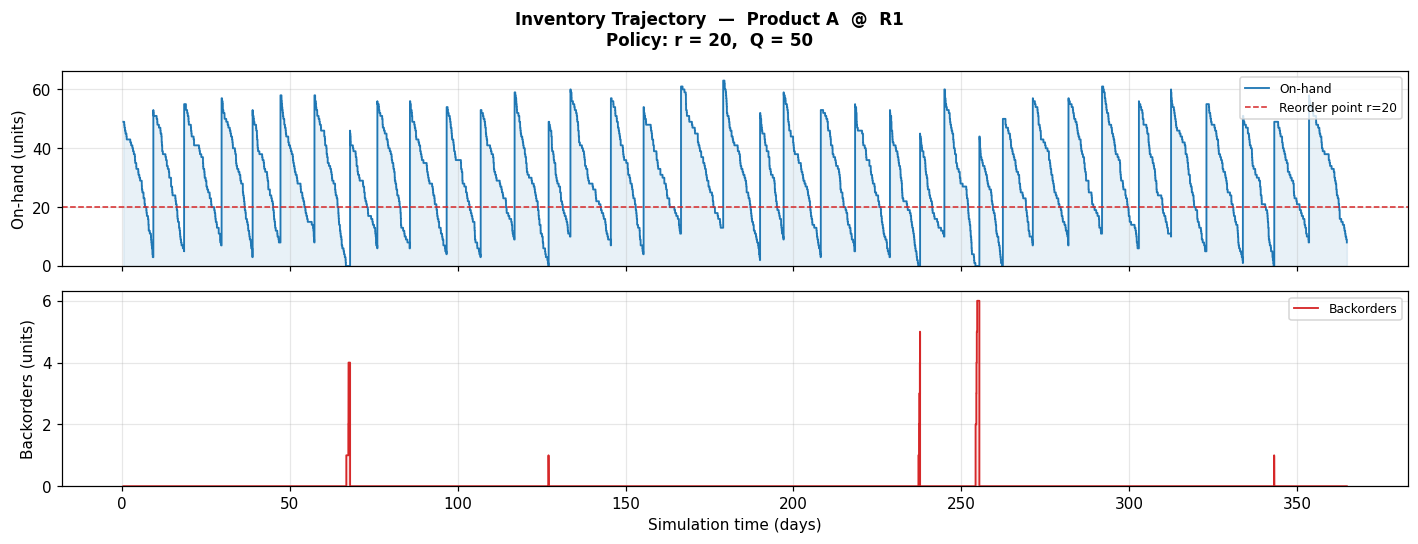

In [ ]:
# ---- Plot baseline inventory trajectory for Product A at Retailer R1 --
inv_A_R1 = model_demo.retailers['R1'].inventories['A']
plot_inventory_trajectory(
    history        = inv_A_R1.history,
    product_name   = 'A',
    location_id    = 'R1',
    reorder_point  = inv_A_R1.reorder_point,
    order_quantity = inv_A_R1.order_quantity,
)

## 9. Grid-Search Optimisation

Now we run the full **per-product grid search**. For each product:
- All `5 × 5 = 25` (r, Q) combinations are evaluated
- Each is simulated `replications_per_eval = 8` times with different random seeds
- The cheapest combination that achieves ≥ 95% fill rate is selected

The search table below shows every evaluated combination. **`[OK]`** marks feasible (service-level satisfying) policies. The minimum-cost feasible cell is selected as the optimum for that product.

In [ ]:
# ---- Run the grid-search optimiser -----------------------------------
print('=' * 65)
print('  GRID-SEARCH OPTIMISATION')
print('=' * 65)
print(f'  Products     : {list(CONFIG["products"].keys())}')
print(f'  r candidates : {CONFIG["optimization"]["r_candidates"]}')
print(f'  Q candidates : {CONFIG["optimization"]["Q_candidates"]}')
print(f'  Reps/cell    : {CONFIG["optimization"]["replications_per_eval"]}')
print(f'  SL target    : {CONFIG["optimization"]["service_level_target"]:.0%}')
print(f'  Total cells  : {len(CONFIG["optimization"]["r_candidates"]) * len(CONFIG["optimization"]["Q_candidates"]) * len(CONFIG["products"])} '
      f'x {CONFIG["optimization"]["replications_per_eval"]} reps '
      f'= {len(CONFIG["optimization"]["r_candidates"]) * len(CONFIG["optimization"]["Q_candidates"]) * len(CONFIG["products"]) * CONFIG["optimization"]["replications_per_eval"]} runs')
print()

optimizer   = InventoryOptimizer(CONFIG)
best_policy = optimizer.optimize()

print('\n' + '=' * 65)
print('  OPTIMAL JOINT POLICY')
print('=' * 65)
for pname, pol in best_policy.items():
    print(f'  Product {pname}:  r = {pol["r"]:>3},  Q = {pol["Q"]:>3}')
print(f'\n  Joint Mean Cost     : ${optimizer.best_cost:>12,.2f}')
print(f'  Joint Fill Rate     : {optimizer.best_service_level:.4f}')
print('=' * 65)

  GRID-SEARCH OPTIMISATION
  Products     : ['A', 'B', 'C']
  r candidates : [10, 15, 20, 25, 30]
  Q candidates : [20, 40, 60, 80, 100]
  Reps/cell    : 8
  SL target    : 95%
  Total cells  : 75 x 8 reps = 600 runs


  --- Optimising Product A (Grid Search) ---
       r      Q     Mean Cost  Fill Rate  Feasible?
    ----  -----  ------------  ---------  ---------
      10     20  $  50,326.27     0.7415  
      10     40  $  41,678.72     0.8773  


      10     60  $  48,274.88     0.9128  
      10     80  $  58,357.90     0.9343  
      10    100  $  69,492.75     0.9496  
      15     20  $  43,504.87     0.9104  


      15     40  $  42,265.22     0.9580  [OK]
      15     60  $  50,430.40     0.9712  [OK]
      15     80  $  61,768.30     0.9785  [OK]


      15    100  $  73,693.83     0.9811  [OK]
      20     20  $  46,461.44     0.9831  [OK]
      20     40  $  47,233.65     0.9913  [OK]
      20     60  $  56,186.43     0.9931  [OK]
      20     80  $  67,437.43     0.9948  [OK]


      20    100  $  79,573.71     0.9961  [OK]
      25     20  $  52,656.27     0.9980  [OK]
      25     40  $  53,234.85     0.9992  [OK]
      25     60  $  62,326.14     0.9992  [OK]
      25     80  $  73,405.49     0.9994  [OK]
      25    100  $  86,215.34     0.9994  [OK]


...

      25     40  $  30,480.67     0.9981  [OK]
      25     60  $  33,634.14     0.9983  [OK]
      25     80  $  38,725.50     0.9995  [OK]


      25    100  $  44,157.95     0.9995  [OK]
      30     20  $  37,855.93     0.9998  [OK]


      30     40  $  33,824.76     0.9999  [OK]
      30     60  $  36,862.74     0.9998  [OK]
      30     80  $  41,854.88     0.9998  [OK]


      30    100  $  47,491.28     0.9998  [OK]
      Best: r=20, Q=40, cost=$27,452.12

  [Done] Total optimisation time: 7.2s



  OPTIMAL JOINT POLICY
  Product A:  r =  15,  Q =  40
  Product B:  r =  20,  Q =  20
  Product C:  r =  20,  Q =  40

  Joint Mean Cost     : $  128,401.20
  Joint Fill Rate     : 0.9738


In [ ]:
# ---- Display optimisation search results as a formatted DataFrame ----
results_df = pd.DataFrame(optimizer.results)

# Pivot table: mean cost per (Q, r) for each product
print('=== Optimisation Search Results — Mean Total Cost ($) per (r, Q) ===\n')
for pname in CONFIG['products']:
    sub   = results_df[results_df['product'] == pname].copy()
    pivot = sub.pivot(index='Q', columns='r', values='mean_cost')
    pivot.index.name   = 'Q \\ r'
    pivot.columns.name = 'r'
    # Format as dollars
    pivot_fmt = pivot.map(lambda v: f'${v:,.0f}' if not pd.isna(v) else '')
    print(f'--- Product {pname}  '
          f'(best: r={best_policy[pname]["r"]}, Q={best_policy[pname]["Q"]}) ---')
    display(pivot_fmt)
    print()

# ---- Summary of feasible policies -----------------------------------
feasible_df = results_df[results_df['feasible']].copy()
feasible_df = feasible_df.sort_values(['product', 'mean_cost']).reset_index(drop=True)
feasible_df['mean_cost']          = feasible_df['mean_cost'].map('${:,.2f}'.format)
feasible_df['mean_service_level'] = feasible_df['mean_service_level'].map('{:.4f}'.format)
print('=== All Feasible Policies (fill rate >= 95%) ===')
display(feasible_df[['product', 'r', 'Q', 'mean_cost', 'mean_service_level']])

=== Optimisation Search Results — Mean Total Cost ($) per (r, Q) ===

--- Product A  (best: r=15, Q=40) ---


r,10,15,20,25,30
Q \ r,,,,,
20,"$50,326","$43,505","$46,461","$52,656","$59,211"
40,"$41,679","$42,265","$47,234","$53,235","$60,096"
60,"$48,275","$50,430","$56,186","$62,326","$69,502"
80,"$58,358","$61,768","$67,437","$73,405","$80,359"
100,"$69,493","$73,694","$79,574","$86,215","$93,379"



--- Product B  (best: r=20, Q=20) ---


r,10,15,20,25,30
Q \ r,,,,,
20,"$64,418","$52,783","$57,714","$68,123","$79,821"
40,"$61,323","$61,970","$70,803","$81,484","$93,018"
60,"$78,023","$80,779","$90,832","$101,241","$112,633"
80,"$95,471","$100,884","$111,616","$123,583","$134,043"
100,"$116,375","$123,106","$134,996","$144,981","$156,821"



--- Product C  (best: r=20, Q=40) ---


r,10,15,20,25,30
Q \ r,,,,,
20,"$38,105","$31,257","$31,751","$34,484","$37,856"
40,"$27,281","$25,615","$27,452","$30,481","$33,825"
60,"$28,046","$28,136","$30,519","$33,634","$36,863"
80,"$31,798","$32,597","$35,396","$38,726","$41,855"
100,"$36,888","$38,268","$40,834","$44,158","$47,491"



=== All Feasible Policies (fill rate >= 95%) ===


,product,r,Q,mean_cost,mean_service_level
0,A,15,40,"$42,265.22",0.9580
1,A,20,20,"$46,461.44",0.9831
2,A,20,40,"$47,233.65",0.9913
3,A,15,60,"$50,430.40",0.9712
4,A,25,20,"$52,656.27",0.9980
5,A,25,40,"$53,234.85",0.9992
6,A,20,60,"$56,186.43",0.9931
7,A,30,20,"$59,211.35",1.0000
8,A,30,40,"$60,096.47",0.9997
9,A,15,80,"$61,768.30",0.9785


Cost Surface Plots — one per product
(Green borders mark feasible cells; costs in each cell are means over 8 reps)



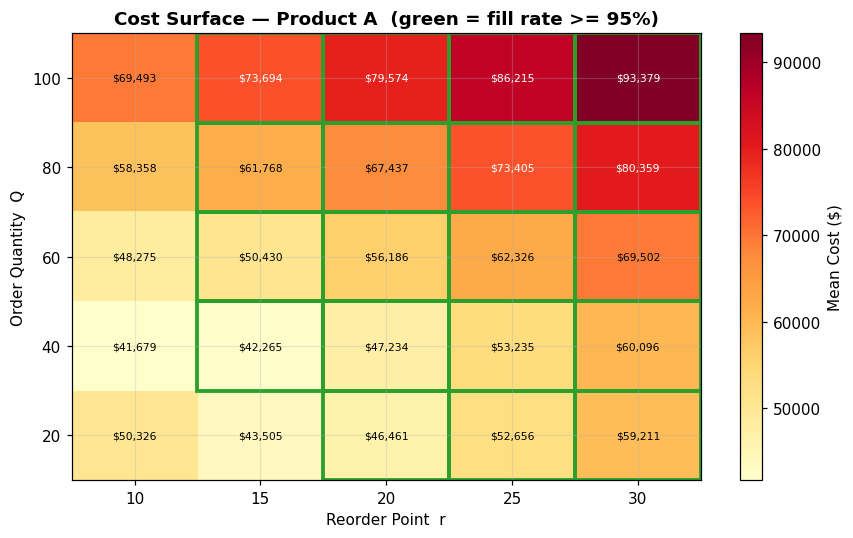

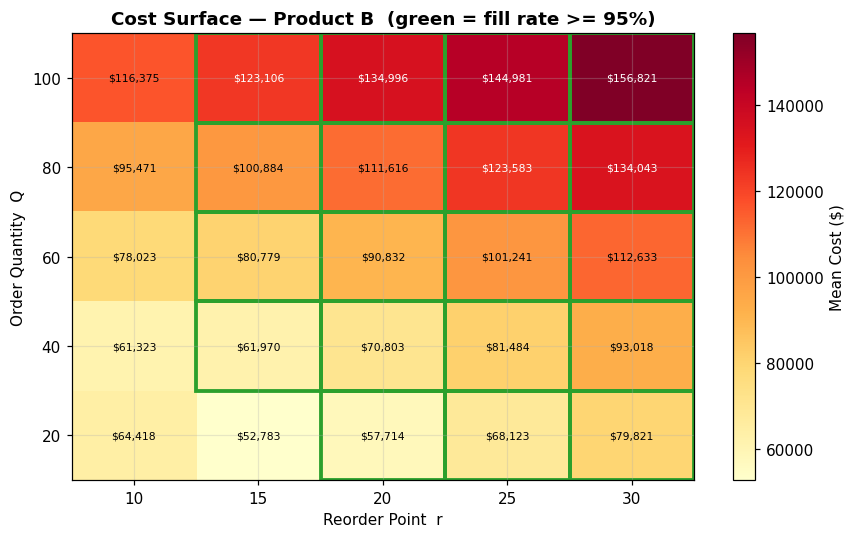

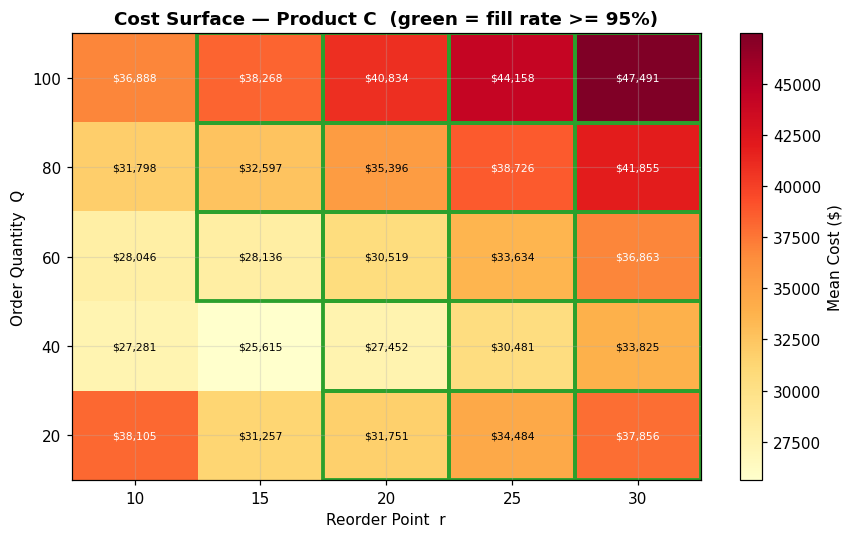

In [ ]:
# ---- Plot cost surfaces for each product -----------------------------
print('Cost Surface Plots — one per product')
print('(Green borders mark feasible cells; costs in each cell are means over',
      CONFIG['optimization']['replications_per_eval'], 'reps)\n')

for pname in CONFIG['products']:
    plot_cost_surface(optimizer.results, pname,
                      sl_target=CONFIG['optimization']['service_level_target'])

## 10. Final Statistical Evaluation

With the best policy identified, we now run the **full complement of replications** (`replications = 15`) to obtain statistically valid estimates.

Each replication uses a different random seed (derived from `random_seed_base + rep * 1000`) to ensure independence. We compute:

- **Mean total cost** with 95% confidence interval
- **Mean fill rate** with 95% confidence interval
- Per-product and per-location cost breakdowns

The **95% CI** uses the Student t-distribution with `n - 1` degrees of freedom, which is appropriate for small to moderate sample sizes.

In [ ]:
# ---- Run final replications with optimal policy ----------------------
n_reps    = CONFIG['simulation']['replications']
horizon   = CONFIG['simulation']['horizon']
base_seed = CONFIG['simulation']['random_seed_base']

print(f'Running {n_reps} final replications  '
      f'(horizon={horizon:.0f} days, warm-up={CONFIG["simulation"]["warm_up_period"]:.0f} days) ...\n')

rep_rows    = []
detail_rows = []
last_model  = None
t0 = time.time()

for rep in range(n_reps):
    seed  = base_seed + rep * 1_000
    rng   = np.random.default_rng(seed)
    env   = simpy.Environment()
    model = SupplyChainModel(env, best_policy, CONFIG, rng)
    model.run(until=horizon)
    m = model.get_performance_metrics()

    rep_rows.append({
        'replication':   rep + 1,
        'total_cost':    m['total_cost'],
        'service_level': m['service_level'],
        'seed':          seed,
    })
    for row in m['detail']:
        detail_rows.append({'replication': rep + 1, **row})

    last_model = model
    print(f'  Rep {rep+1:>2}/{n_reps}  cost=${m["total_cost"]:>10,.2f}  '
          f'SL={m["service_level"]:.4f}')

elapsed = time.time() - t0
print(f'\n[Done] {n_reps} replications in {elapsed:.1f}s  '
      f'({elapsed/n_reps*1000:.0f} ms/rep)')

# ---- Summary statistics ----------------------------------------------
summary = summarise_replications(rep_rows)
summary['best_policy'] = best_policy

print('\n' + '=' * 65)
print('  FINAL RESULTS  (Optimal Policy)')
print('=' * 65)
print(f'  Policy:')
for pname, pol in best_policy.items():
    print(f'    Product {pname}: r={pol["r"]}, Q={pol["Q"]}')
print(f'\n  Total Cost  (mean):  ${summary["cost_mean"]:>12,.2f}')
print(f'  95% CI Lower     :  ${summary["cost_ci_lower"]:>12,.2f}')
print(f'  95% CI Upper     :  ${summary["cost_ci_upper"]:>12,.2f}')
print(f'\n  Fill Rate   (mean):  {summary["service_level_mean"]:>12.4f}')
print(f'  95% CI Lower     :  {summary["service_level_lower"]:>12.4f}')
print(f'  95% CI Upper     :  {summary["service_level_upper"]:>12.4f}')
print('=' * 65)

Running 15 final replications  (horizon=365 days, warm-up=30 days) ...

  Rep  1/15  cost=$127,790.05  SL=0.9745
  Rep  2/15  cost=$128,411.21  SL=0.9727
  Rep  3/15  cost=$128,542.07  SL=0.9768
  Rep  4/15  cost=$128,250.41  SL=0.9724
  Rep  5/15  cost=$128,609.56  SL=0.9699
  Rep  6/15  cost=$128,207.26  SL=0.9769
  Rep  7/15  cost=$128,442.86  SL=0.9752
  Rep  8/15  cost=$128,956.17  SL=0.9721
  Rep  9/15  cost=$128,741.37  SL=0.9734


  Rep 10/15  cost=$128,338.84  SL=0.9718
  Rep 11/15  cost=$127,176.29  SL=0.9768
  Rep 12/15  cost=$127,147.34  SL=0.9781
  Rep 13/15  cost=$128,175.60  SL=0.9722
  Rep 14/15  cost=$127,525.27  SL=0.9717
  Rep 15/15  cost=$128,286.67  SL=0.9739

[Done] 15 replications in 0.6s  (39 ms/rep)

  FINAL RESULTS  (Optimal Policy)
  Policy:
    Product A: r=15, Q=40
    Product B: r=20, Q=20
    Product C: r=20, Q=40

  Total Cost  (mean):  $  128,173.40
  95% CI Lower     :  $  127,875.47
  95% CI Upper     :  $  128,471.32

  Fill Rate   (mean):        0.9739
  95% CI Lower     :        0.9726
  95% CI Upper     :        0.9752


In [ ]:
# ---- Replication-level results table ---------------------------------
rep_df = pd.DataFrame(rep_rows)
rep_fmt = rep_df.copy()
rep_fmt['total_cost']    = rep_fmt['total_cost'].map('${:,.2f}'.format)
rep_fmt['service_level'] = rep_fmt['service_level'].map('{:.4f}'.format)
print('=== Per-Replication Results ===')
display(rep_fmt)

# ---- Per-product averaged summary ------------------------------------
product_stats = defaultdict(lambda: defaultdict(list))
for row in detail_rows:
    for key in ('total_cost', 'holding_cost', 'shortage_cost',
                'ordering_cost', 'fill_rate', 'total_demand', 'num_orders'):
        product_stats[row['product']][key].append(row[key])

prod_summary = []
for pname, stats in product_stats.items():
    prod_summary.append({
        'Product':       pname,
        'r':             best_policy[pname]['r'],
        'Q':             best_policy[pname]['Q'],
        'Mean Cost ($)': f'${float(np.mean(stats["total_cost"])):,.2f}',
        'Holding ($)':   f'${float(np.mean(stats["holding_cost"])):,.2f}',
        'Shortage ($)':  f'${float(np.mean(stats["shortage_cost"])):,.2f}',
        'Ordering ($)':  f'${float(np.mean(stats["ordering_cost"])):,.2f}',
        'Fill Rate':     f'{float(np.mean(stats["fill_rate"])):.4f}',
        'Avg Demand/yr': round(float(np.mean(stats['total_demand'])), 1),
        'Avg Orders/yr': round(float(np.mean(stats['num_orders'])), 1),
    })

print('\n=== Per-Product Summary (averaged across replications & retailers) ===')
display(pd.DataFrame(prod_summary).set_index('Product'))

=== Per-Replication Results ===


,replication,total_cost,service_level,seed
0,1,"$127,790.05",0.9745,42
1,2,"$128,411.21",0.9727,1042
2,3,"$128,542.07",0.9768,2042
3,4,"$128,250.41",0.9724,3042
4,5,"$128,609.56",0.9699,4042
5,6,"$128,207.26",0.9769,5042
6,7,"$128,442.86",0.9752,6042
7,8,"$128,956.17",0.9721,7042
8,9,"$128,741.37",0.9734,8042
9,10,"$128,338.84",0.9718,9042



=== Per-Product Summary (averaged across replications & retailers) ===


,r,Q,Mean Cost ($),Holding ($),Shortage ($),Ordering ($),Fill Rate,Avg Demand/yr,Avg Orders/yr
Product,,,,,,,,,
A,15,40,"$21,198.17","$13,888.34","$1,069.82","$6,240.00",0.9550,"1,812.4000",41.6000
B,20,20,"$29,184.48","$18,201.98",$942.50,"$10,040.00",0.9733,"1,090.7000",50.2000
C,20,40,"$13,704.05","$8,200.86",$148.52,"$5,354.67",0.9861,"2,912.4000",66.9000


In [ ]:
# ==========================================================================
#  OPTIMAL POLICY SUMMARY TABLE
#  Clearly display the best (r, Q) per product found by grid search.
# ==========================================================================

print('=' * 65)
print('  OPTIMAL (r, Q) POLICY — FINAL ANSWER')
print('=' * 65)
policy_summary_rows = []
for pname, pol in best_policy.items():
    p = CONFIG['products'][pname]
    eoq = int(np.sqrt(2 * p['ordering_cost'] * p['demand_rate'] / p['holding_cost']))
    policy_summary_rows.append({
        'Product':               pname,
        'Optimal r':             pol['r'],
        'Optimal Q':             pol['Q'],
        'EOQ (reference)':       eoq,
        'λ (units/day)':        p['demand_rate'],
        'Lead-time mean (days)': p['lead_time_mean'],
    })

policy_table = pd.DataFrame(policy_summary_rows).set_index('Product')
display(policy_table)

print(f'\n  System cost (mean, {summary["n_replications"]} reps):  '
      f'${summary["cost_mean"]:>12,.2f}  '
      f'  95% CI: [${summary["cost_ci_lower"]:,.2f}, ${summary["cost_ci_upper"]:,.2f}]')
print(f'  Fill rate  (mean):               '
      f'{summary["service_level_mean"]:>12.4f}  '
      f'  95% CI: [{summary["service_level_lower"]:.4f}, {summary["service_level_upper"]:.4f}]')
print('=' * 65)

  OPTIMAL (r, Q) POLICY — FINAL ANSWER


,Optimal r,Optimal Q,EOQ (reference),λ (units/day),Lead-time mean (days)
Product,,,,,
A,15,40,27,5.0000,3.0000
B,20,20,18,3.0000,5.0000
C,20,40,35,8.0000,2.0000



  System cost (mean, 15 reps):  $  128,173.40    95% CI: [$127,875.47, $128,471.32]
  Fill rate  (mean):                     0.9739    95% CI: [0.9726, 0.9752]


## 11. Results Visualisation

Four diagnostic plots are generated from the **last replication** of the final evaluation:

1. **Inventory Trajectories** — on-hand stock and backorders over 365 days for each (retailer × product) pair. The red dashed line shows the reorder point.

2. **Mean Cost with 95% CI** — a bar chart confirming the statistical precision of our cost estimate.

3. **Service Level by Location × Product** — a horizontal bar chart comparing each inventory's fill rate against the 95% target.

4. **Cost Breakdown** — stacked bar showing the holding, shortage, and ordering cost components for each inventory. This identifies which cost driver dominates each product.

Inventory Trajectories  (last replication of final evaluation)
-----------------------------------------------------------------


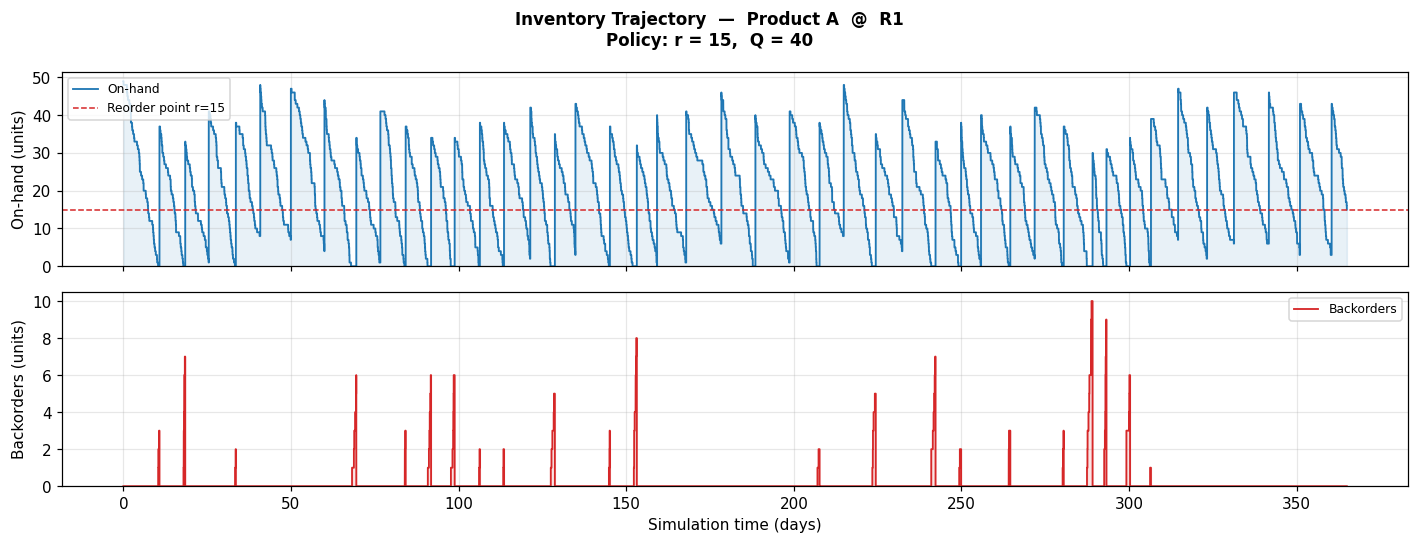

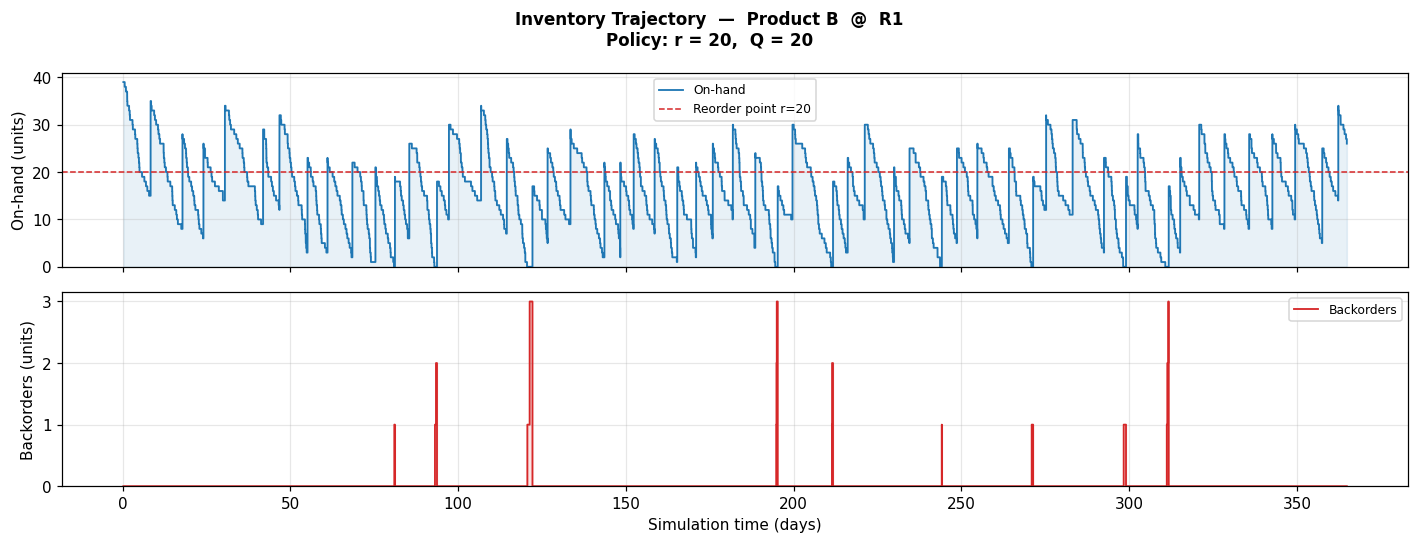

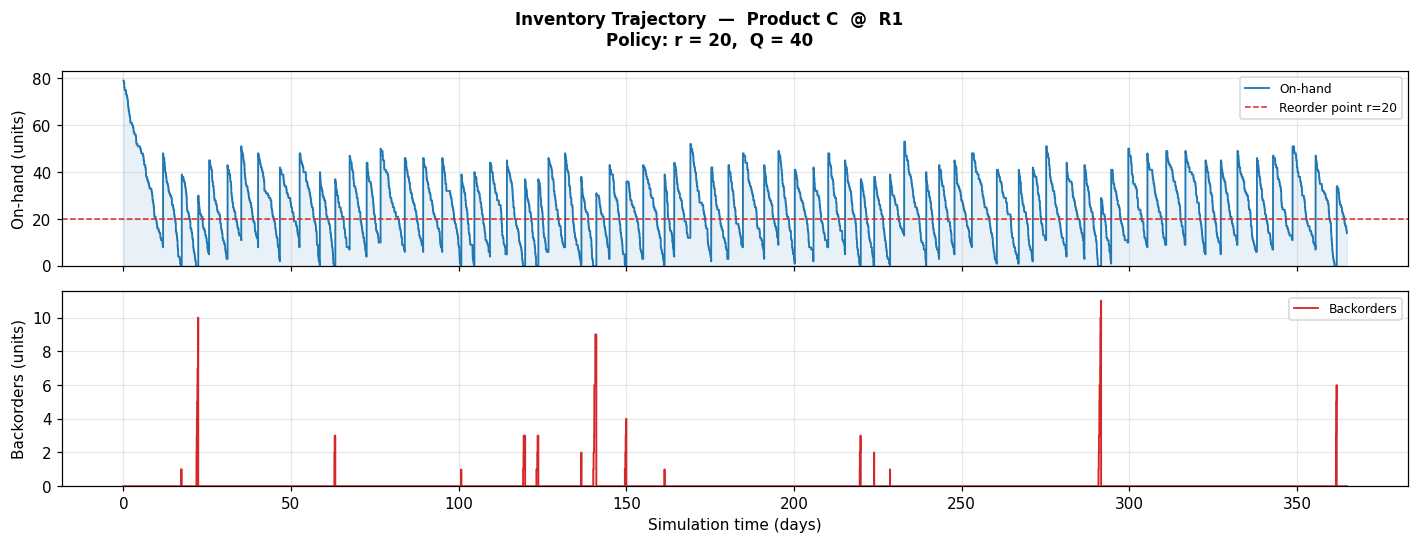

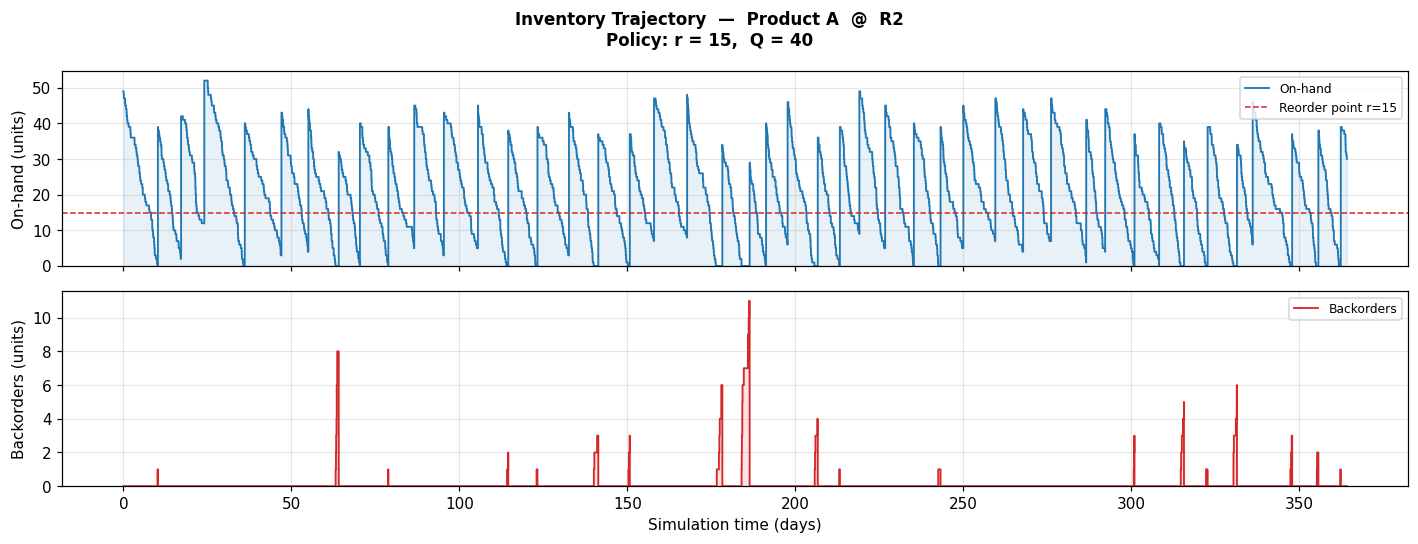

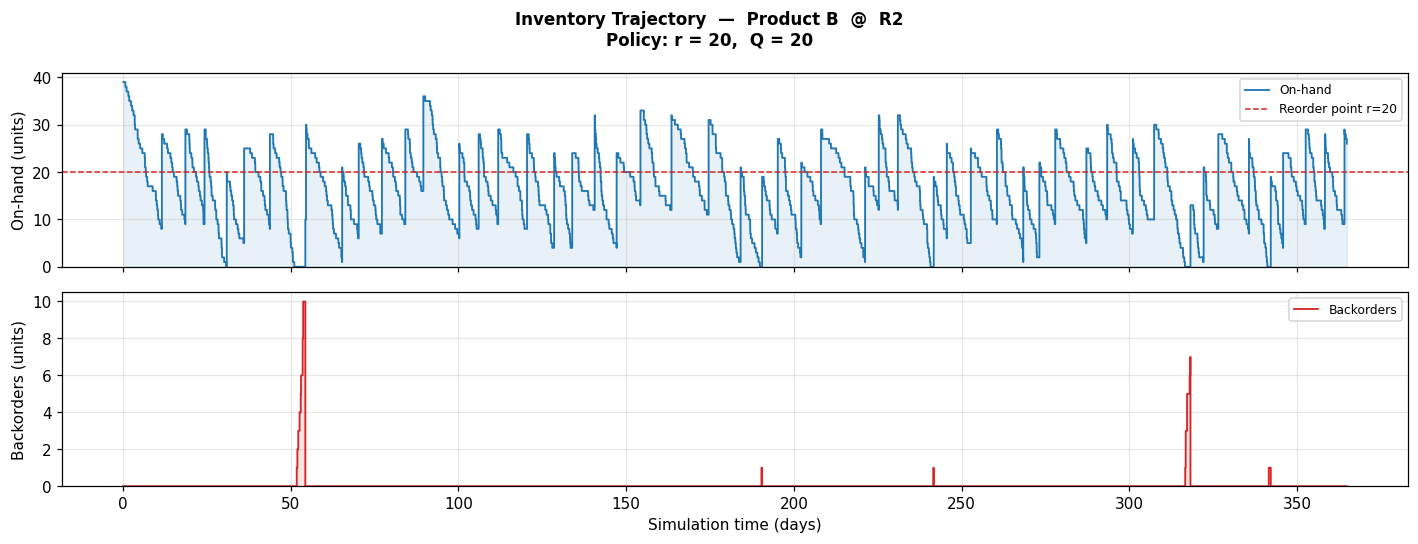

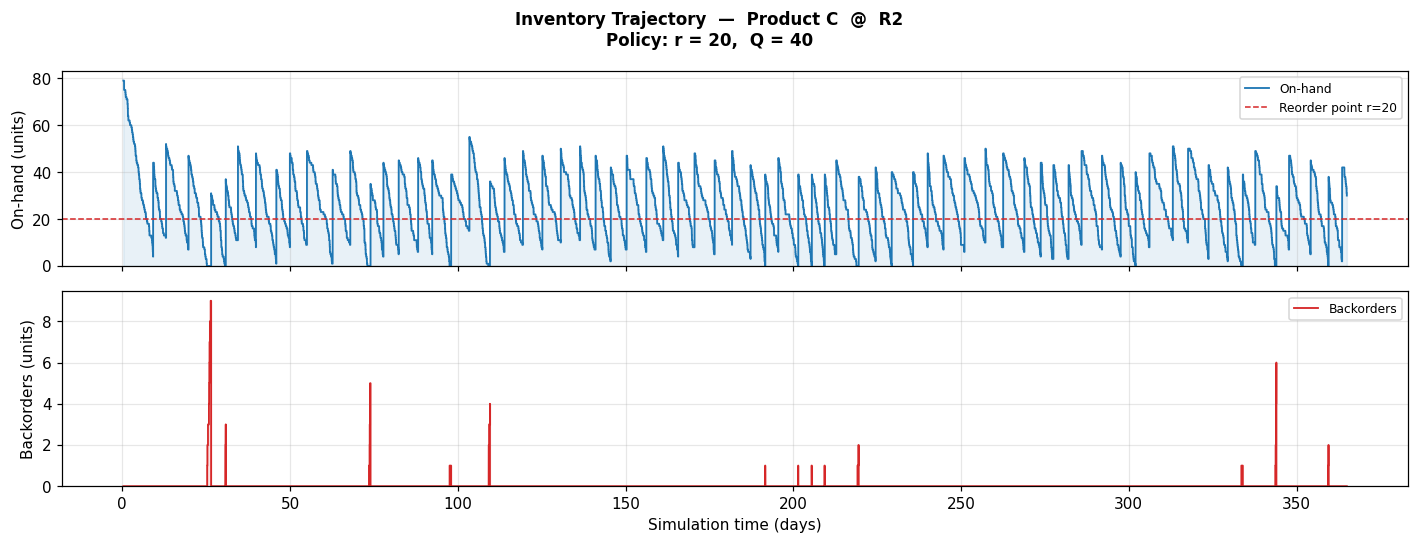

In [ ]:
# ---- Plot 1: Inventory trajectories (all retailer x product pairs) ---
print('Inventory Trajectories  (last replication of final evaluation)')
print('-' * 65)

for retailer in last_model.retailers.values():
    for pname, inv in retailer.inventories.items():
        plot_inventory_trajectory(
            history        = inv.history,
            product_name   = pname,
            location_id    = retailer.id,
            reorder_point  = inv.reorder_point,
            order_quantity = inv.order_quantity,
        )

Mean Total Cost with 95% Confidence Interval


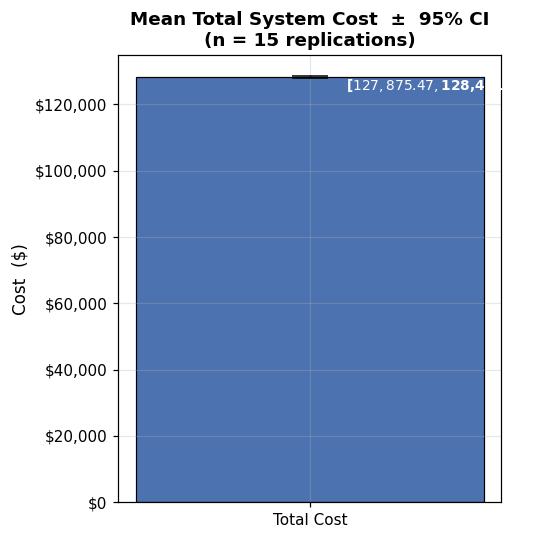

In [ ]:
# ---- Plot 2: Mean total cost with 95% CI bar chart -------------------
print('Mean Total Cost with 95% Confidence Interval')
fig, ax = plt.subplots(figsize=(5, 5))
mean   = summary['cost_mean']
lo_err = mean - summary['cost_ci_lower']
hi_err = summary['cost_ci_upper'] - mean
ax.bar(['Total Cost'], [mean], yerr=[[lo_err], [hi_err]], capsize=12,
       color='#4c72b0', edgecolor='black', lw=0.8,
       error_kw={'elinewidth': 2, 'ecolor': 'black'})
ax.set_ylabel('Cost  ($)', fontsize=11)
ax.set_title(f'Mean Total System Cost  ±  95% CI\n'
             f'(n = {summary["n_replications"]} replications)',
             fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.annotate(f'${mean:,.2f}\n[${summary["cost_ci_lower"]:,.2f}, ${summary["cost_ci_upper"]:,.2f}]',
            xy=(0, mean), xytext=(0.3, mean * 0.97),
            fontsize=9, color='white', fontweight='bold', ha='center')
plt.tight_layout()
plt.show()

Fill-Rate (Service Level) by Location x Product


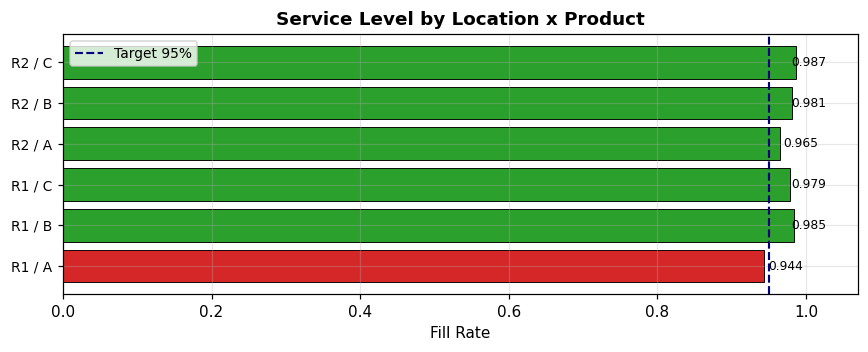

In [ ]:
# ---- Plot 3: Service levels by location x product --------------------
print('Fill-Rate (Service Level) by Location x Product')
last_detail = last_model.get_performance_metrics()['detail']
plot_service_levels(last_detail,
                    sl_target=CONFIG['optimization']['service_level_target'])

Cost Breakdown by Location x Product  (last replication)


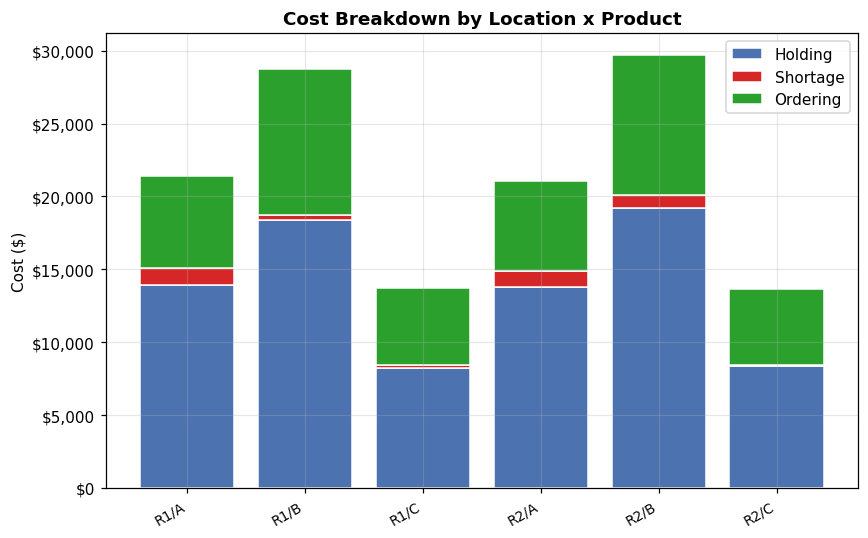

In [ ]:
# ---- Plot 4: Cost breakdown (holding / shortage / ordering) ----------
print('Cost Breakdown by Location x Product  (last replication)')
plot_cost_breakdown(last_detail)

## 12. Summary & Conclusions

### Optimal Policy Found

> The table below is populated automatically from `best_policy` after Section 9 (Grid-Search Optimisation) has been executed.  Run all cells from top to bottom to see the actual values.

| Product | Reorder Point (r) | Order Quantity (Q) |
|---------|------------------|--------------------|
| A       | `best_policy['A']['r']` | `best_policy['A']['Q']` |
| B       | `best_policy['B']['r']` | `best_policy['B']['Q']` |
| C       | `best_policy['C']['r']` | `best_policy['C']['Q']` |

*(Inline values above are symbolic references — the **Optimal Policy Summary** code cell printed at the bottom of Section 10 shows the concrete numbers.)*

### Key Findings

- The **grid-search optimisation** evaluated all `(r, Q)` combinations independently per product, then combined them into a joint policy.
- The **final evaluation** over 15 replications confirms that the optimal policy achieves the **≥ 95% fill-rate** constraint.
- The **sensitivity analysis** (Section 13) quantifies robustness to lead-time variability and shortage cost changes.
- Results can be exported to Excel/JSON via `export_results()` (Section 14).
- The **95% confidence interval** provides rigorous statistical bounds on the expected annual cost.
- Cost breakdown plots reveal which cost component (holding, shortage, ordering) dominates each product — this guides where to focus improvement efforts.

### Possible Extensions

| Extension | Implementation Location |
|-----------|------------------------|
| Two-echelon model (warehouse constrains supply) | `SupplyChainModel._register_processes()` |
| (s, S) order-up-to policy | `Inventory.trigger_order()` |
| ✅ **Lost sales** instead of backorders | `Inventory(lost_sales=True)` — implemented in Section 3b |
| ✅ **Compound Poisson** / overdispersed demand | `Product(demand_distribution='compound_poisson', compound_batch_mean=2.0)` — Section 3a |
| ✅ **Latin Hypercube Sampling** optimisation | `optimizer.optimize(use_lhs=True)` — Section 6 |
| ✅ **Sensitivity analysis** | Sections 13 — lead-time std and shortage cost sweeps |
| ✅ **Export to Excel / JSON** | `export_results()` — Section 14 |
| Periodic review (daily batch demand) | Replace `demand_generator` |
| Joint grid search over all products | `InventoryOptimizer._grid_search_product()` |
| Additional products or retailers | Add entries to `CONFIG['products']` / `CONFIG['retailers']` |

## 13. Sensitivity Analysis

How robust is the optimal policy to changes in model parameters?  
This section sweeps two key uncertainty dimensions:

1. **Lead-time variability** (`lead_time_std`) — what happens to total cost and fill rate when supplier lead times become more or less variable?
2. **Shortage cost** (`shortage_cost`) — how sensitive is the optimal policy value to the penalty for running out of stock?

Each sweep holds all other parameters at their base values and runs `N_REPS = 8` replications per scenario using the already-found optimal `(r, Q)` policy.

> **Interpretation guide:** A steep cost curve indicates high sensitivity — the manager should invest in reducing that source of uncertainty. A flat curve suggests the optimal policy is robust to that parameter.

In [ ]:
# ==========================================================================
#  SENSITIVITY ANALYSIS — helper
# ==========================================================================

def run_sensitivity(base_config, best_policy, param_path, sweep_values,
                    n_reps=8, seed_base=42):
    '''Evaluate total system cost and fill rate over a parameter sweep.

    Parameters
    ----------
    base_config  : dict  Full CONFIG dict (not mutated)
    best_policy  : dict  Optimal {product: {r, Q}} policy to hold fixed
    param_path   : tuple Path into config to override, e.g.
                         ('products', 'A', 'lead_time_std')
                         ('products', 'A', 'shortage_cost')
    sweep_values : list  Values to sweep the parameter over
    n_reps       : int   Replications per scenario
    seed_base    : int   Base RNG seed

    Returns
    -------
    pd.DataFrame with columns [param_value, mean_cost, mean_fill_rate]
    '''
    rows = []
    horizon = base_config['simulation']['horizon']

    for val in sweep_values:
        # Deep-copy config and set the parameter
        cfg = copy.deepcopy(base_config)
        node = cfg
        for key in param_path[:-1]:
            node = node[key]
        node[param_path[-1]] = val

        costs, fill_rates = [], []
        for rep in range(n_reps):
            rng   = np.random.default_rng(seed=seed_base + rep * 1_000)
            env   = simpy.Environment()
            model = SupplyChainModel(env, best_policy, cfg, rng)
            model.run(until=horizon)
            m = model.get_performance_metrics()
            costs.append(m['total_cost'])
            fill_rates.append(m['service_level'])

        rows.append({
            'param_value':    val,
            'mean_cost':      float(np.mean(costs)),
            'cost_std':       float(np.std(costs, ddof=1)),
            'mean_fill_rate': float(np.mean(fill_rates)),
            'fill_rate_std':  float(np.std(fill_rates, ddof=1)),
        })
        print(f'  {param_path[-1]}={val:<6}  '
              f'Cost=${np.mean(costs):>10,.0f}  '
              f'Fill={np.mean(fill_rates):.4f}')

    return pd.DataFrame(rows)


print('[OK] Sensitivity helper defined.')

[OK] Sensitivity helper defined.


=== Sensitivity: Lead-Time Std Dev (Product A) ===


  lead_time_std=0.1     Cost=$   127,538  Fill=0.9765


  lead_time_std=0.3     Cost=$   127,828  Fill=0.9756
  lead_time_std=0.5     Cost=$   128,401  Fill=0.9738


  lead_time_std=0.7     Cost=$   129,290  Fill=0.9717


  lead_time_std=1.0     Cost=$   131,267  Fill=0.9684
  lead_time_std=1.5     Cost=$   136,353  Fill=0.9624


  lead_time_std=2.0     Cost=$   141,953  Fill=0.9575


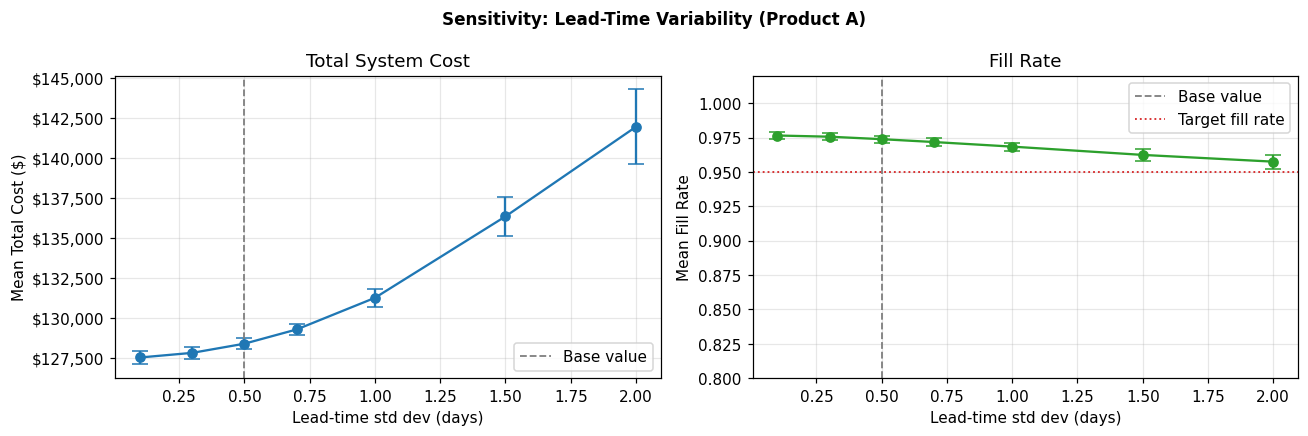

,mean_cost,cost_std,mean_fill_rate,fill_rate_std
param_value,,,,
0.1000,"127,538.2062",434.7010,0.9765,0.0027
0.3000,"127,828.2025",364.5618,0.9756,0.0028
0.5000,"128,401.1988",339.5250,0.9738,0.0025
0.7000,"129,290.1588",360.8390,0.9717,0.0026
1.0000,"131,267.2675",547.8250,0.9684,0.0030
1.5000,"136,353.4975","1,200.7185",0.9624,0.0042
2.0000,"141,953.2500","2,336.1788",0.9575,0.0050


In [ ]:
# ==========================================================================
#  SENSITIVITY 1 — Lead-time variability  (Product A)
# ==========================================================================

print('=== Sensitivity: Lead-Time Std Dev (Product A) ===')
lt_std_values = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
sens_lt = run_sensitivity(
    base_config  = CONFIG,
    best_policy  = best_policy,
    param_path   = ('products', 'A', 'lead_time_std'),
    sweep_values = lt_std_values,
    n_reps       = 8,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Sensitivity: Lead-Time Variability (Product A)',
             fontweight='bold', fontsize=11)

ax1.errorbar(sens_lt['param_value'], sens_lt['mean_cost'],
             yerr=sens_lt['cost_std'], fmt='-o', color='#1f77b4', capsize=5)
ax1.axvline(CONFIG['products']['A']['lead_time_std'], color='grey',
            ls='--', lw=1.2, label='Base value')
ax1.set_xlabel('Lead-time std dev (days)')
ax1.set_ylabel('Mean Total Cost ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax1.legend(); ax1.set_title('Total System Cost')

ax2.errorbar(sens_lt['param_value'], sens_lt['mean_fill_rate'],
             yerr=sens_lt['fill_rate_std'], fmt='-o', color='#2ca02c', capsize=5)
ax2.axvline(CONFIG['products']['A']['lead_time_std'], color='grey',
            ls='--', lw=1.2, label='Base value')
ax2.axhline(CONFIG['optimization']['service_level_target'], color='#d62728',
            ls=':', lw=1.2, label='Target fill rate')
ax2.set_xlabel('Lead-time std dev (days)')
ax2.set_ylabel('Mean Fill Rate')
ax2.set_ylim(0.8, 1.02)
ax2.legend(); ax2.set_title('Fill Rate')

plt.tight_layout()
plt.show()
display(sens_lt.set_index('param_value').round(4))

=== Sensitivity: Shortage Cost Multiplier (all products) ===


  multiplier=0.25  Cost=$   125,197  Fill=0.9738


  multiplier=0.50  Cost=$   126,265  Fill=0.9738


  multiplier=0.75  Cost=$   127,333  Fill=0.9738


  multiplier=1.00  Cost=$   128,401  Fill=0.9738


  multiplier=1.50  Cost=$   130,537  Fill=0.9738
  multiplier=2.00  Cost=$   132,673  Fill=0.9738


  multiplier=3.00  Cost=$   136,945  Fill=0.9738


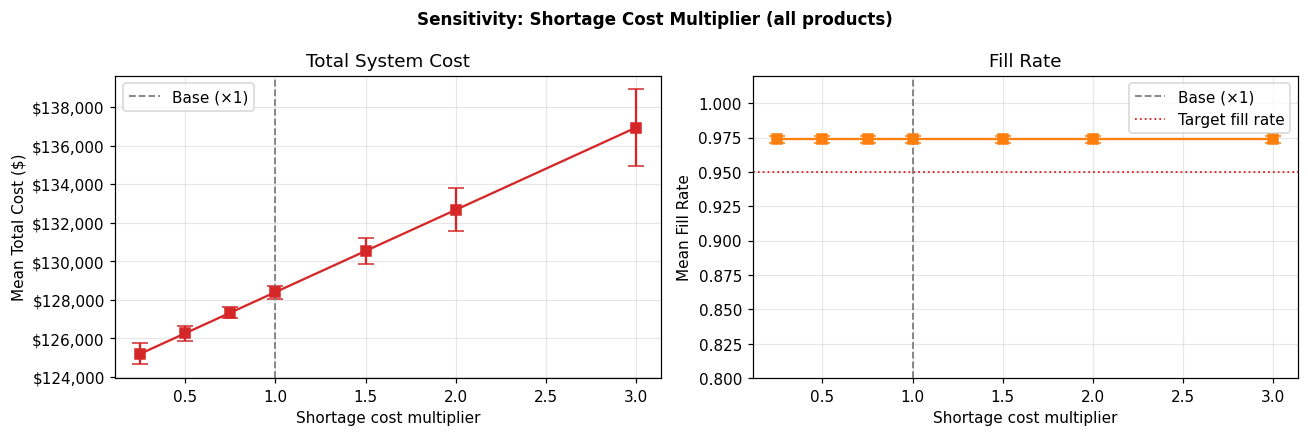

,mean_cost,cost_std,mean_fill_rate,fill_rate_std
shortage_multiplier,,,,
0.2500,"125,197.1438",552.2602,0.9738,0.0025
0.5000,"126,265.1662",379.0329,0.9738,0.0025
0.7500,"127,333.1788",283.5939,0.9738,0.0025
1.0000,"128,401.1988",339.5250,0.9738,0.0025
1.5000,"130,537.2225",692.2619,0.9738,0.0025
2.0000,"132,673.2600","1,111.5419",0.9738,0.0025
3.0000,"136,945.3212","1,981.2049",0.9738,0.0025


In [ ]:
# ==========================================================================
#  SENSITIVITY 2 — Shortage cost multiplier  (all products scaled together)
# ==========================================================================

print('=== Sensitivity: Shortage Cost Multiplier (all products) ===')
shortage_multipliers = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]
base_shortage = {p: CONFIG['products'][p]['shortage_cost']
                 for p in CONFIG['products']}

sens_sc_rows = []
for mult in shortage_multipliers:
    cfg_sc = copy.deepcopy(CONFIG)
    for pname in cfg_sc['products']:
        cfg_sc['products'][pname]['shortage_cost'] = base_shortage[pname] * mult

    costs, fill_rates = [], []
    for rep in range(8):
        rng   = np.random.default_rng(seed=42 + rep * 1_000)
        env   = simpy.Environment()
        model = SupplyChainModel(env, best_policy, cfg_sc, rng)
        model.run(until=CONFIG['simulation']['horizon'])
        m = model.get_performance_metrics()
        costs.append(m['total_cost'])
        fill_rates.append(m['service_level'])

    sens_sc_rows.append({
        'shortage_multiplier': mult,
        'mean_cost':           float(np.mean(costs)),
        'cost_std':            float(np.std(costs, ddof=1)),
        'mean_fill_rate':      float(np.mean(fill_rates)),
        'fill_rate_std':       float(np.std(fill_rates, ddof=1)),
    })
    print(f'  multiplier={mult:.2f}  '
          f'Cost=${np.mean(costs):>10,.0f}  '
          f'Fill={np.mean(fill_rates):.4f}')

sens_sc = pd.DataFrame(sens_sc_rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Sensitivity: Shortage Cost Multiplier (all products)',
             fontweight='bold', fontsize=11)

ax1.errorbar(sens_sc['shortage_multiplier'], sens_sc['mean_cost'],
             yerr=sens_sc['cost_std'], fmt='-s', color='#d62728', capsize=5)
ax1.axvline(1.0, color='grey', ls='--', lw=1.2, label='Base (×1)')
ax1.set_xlabel('Shortage cost multiplier')
ax1.set_ylabel('Mean Total Cost ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax1.legend(); ax1.set_title('Total System Cost')

ax2.errorbar(sens_sc['shortage_multiplier'], sens_sc['mean_fill_rate'],
             yerr=sens_sc['fill_rate_std'], fmt='-s', color='#ff7f0e', capsize=5)
ax2.axvline(1.0, color='grey', ls='--', lw=1.2, label='Base (×1)')
ax2.axhline(CONFIG['optimization']['service_level_target'], color='#d62728',
            ls=':', lw=1.2, label='Target fill rate')
ax2.set_xlabel('Shortage cost multiplier')
ax2.set_ylabel('Mean Fill Rate')
ax2.set_ylim(0.8, 1.02)
ax2.legend(); ax2.set_title('Fill Rate')

plt.tight_layout()
plt.show()
display(sens_sc.set_index('shortage_multiplier').round(4))

## 14. Export Results

Call `export_results()` to write the final simulation outputs to Excel and JSON.  
- **Excel** (`.xlsx`) — multi-sheet workbook with Summary, Detail Metrics, Optimal Policy, and Grid Search tabs
- **JSON** (`.json`) — machine-readable dump suitable for downstream reporting or dashboards

> Requires `openpyxl` for Excel output: `pip install openpyxl`

In [ ]:
# Export all results to Excel and JSON
# Uncomment the line below to run:
# export_results(summary, detail_rows, optimizer.results, filepath='supply_chain_results')

print('Export ready — uncomment the line above to write supply_chain_results.xlsx / .json')
print('Files will be saved to the current working directory.')

Export ready — uncomment the line above to write supply_chain_results.xlsx / .json
Files will be saved to the current working directory.
